# EMiF Project — Risk Structure After COVID-19

## Research question

Can we say that, since COVID-19, the structure of risk in financial markets has changed?

This notebook reproduces the empirical analysis used in the report. The analysis uses only the dataset provided in `Data.xlsx` and does not require external market data or hidden Python modules.

We define the "structure of risk" as five dimensions:

1. Risk levels: volatility, tail risk, skewness and kurtosis.
2. Risk co-movement: pairwise correlations and asset-class block correlations.
3. Full co-movement structure: the global correlation-matrix shift.
4. Risk factors: principal-component concentration and common shocks.
5. Portfolio implications: diversification, minimum-variance weights and equal-risk-contribution weights.

The notebook combines descriptive evidence with formal bootstrap tests, Fisher correlation tests, a correlation-matrix distance test, a structural-break analysis of equity-bond diversification, and portfolio exercises.


In [58]:
from pathlib import Path
import math
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

try:
    from scipy.optimize import minimize
except ImportError:
    minimize = None

print("Libraries imported successfully.")


Libraries imported successfully.


In [59]:
CURRENT_DIR = Path.cwd()

possible_paths = [
    CURRENT_DIR / "Data.xlsx",
    CURRENT_DIR / "data" / "Data.xlsx",
    CURRENT_DIR.parent / "Data.xlsx",
    CURRENT_DIR.parent / "data" / "Data.xlsx",
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Data.xlsx not found. Please place Data.xlsx in the same folder as the notebook "
        "or in a data/ folder."
    )

print("Using data file:", DATA_PATH)
print("Notebook mode: self-contained analysis code with inline outputs.")
print("No tables or figures are written to a results folder.")


Using data file: c:\Users\ish4q\Desktop\emif 2\data\Data.xlsx
Notebook mode: self-contained analysis code with inline outputs.
No tables or figures are written to a results folder.


## Helper functions

The following helper functions are included directly in the notebook to make the analysis fully reproducible from the notebook and `Data.xlsx`, without requiring external Python modules.

In [60]:
def load_raw_data(path):
    """
    Load the raw Excel file provided for the EMiF project.
    The function assumes the first column is a date column.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_excel(path)

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\n", " ", regex=False)
        .str.replace("  ", " ", regex=False)
    )

    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    df = df.dropna(subset=[date_col])
    df = df.set_index(date_col)
    df.index.name = "Date"
    df = df.sort_index()

    return df

In [61]:
LOG_RETURN_COLUMNS = [
    "S&P500",
    "Eurostoxx 50",
    "Hang Seng",
    "MSCI EM",
    "SMI",
    "Gold",
    "EURUSD",
    "USDJPY",
    "US IG Bonds",
    "US HY Bonds",
    "USDCHF",
]

YIELD_COLUMNS = [
    "US T 10-year Yield",
    "German Gov 10-year yield",
]


def prepare_returns(raw_df):
    """
    Convert raw market data into stationary financial series.

    - Price/index/bond/FX series are transformed into log returns.
    - Government bond yields are transformed into daily changes in basis points.
    - Oil futures are transformed with an asinh difference because oil prices became
      negative in April 2020, making log returns impossible.
    """

    df = raw_df.copy()
    df.index.name = "Date"

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    transformed = pd.DataFrame(index=df.index)

    for col in LOG_RETURN_COLUMNS:
        transformed[col] = np.log(df[col] / df[col].shift(1))

    for col in YIELD_COLUMNS:
        transformed[col] = df[col].diff() * 100

    transformed["Oil futures"] = (
        np.arcsinh(df["Oil futures"]) - np.arcsinh(df["Oil futures"].shift(1))
    )

    transformed = transformed[df.columns]
    transformed = transformed.dropna(how="any")

    return transformed


def split_pre_post_covid(returns_df, breakpoint="2020-03-11"):
    """
    Split the dataset into pre-COVID and post-COVID samples.
    """

    breakpoint = pd.to_datetime(breakpoint)

    pre_covid = returns_df.loc[returns_df.index < breakpoint].copy()
    post_covid = returns_df.loc[returns_df.index >= breakpoint].copy()

    return pre_covid, post_covid

In [62]:
def compute_skewness(series):
    x = pd.Series(series).dropna()
    mean = x.mean()
    std = x.std(ddof=0)

    if std == 0:
        return np.nan

    return np.mean(((x - mean) / std) ** 3)


def compute_excess_kurtosis(series):
    x = pd.Series(series).dropna()
    mean = x.mean()
    std = x.std(ddof=0)

    if std == 0:
        return np.nan

    kurtosis = np.mean(((x - mean) / std) ** 4)

    return kurtosis - 3


def compute_jarque_bera(series):
    x = pd.Series(series).dropna()
    t = len(x)

    s = compute_skewness(x)
    k = compute_excess_kurtosis(x)

    jb_stat = t * ((s**2) / 6 + (k**2) / 24)
    jb_pvalue = np.exp(-jb_stat / 2)

    return jb_stat, jb_pvalue


def compute_risk_metrics(returns_df, annualization=252):
    rows = []

    for col in returns_df.columns:
        series = returns_df[col].dropna()

        var_5 = series.quantile(0.05)
        cvar_5 = series[series <= var_5].mean()

        jb_stat, jb_pvalue = compute_jarque_bera(series)

        rows.append(
            {
                "Asset": col,
                "Mean_ann": series.mean() * annualization,
                "Vol_ann": series.std() * np.sqrt(annualization),
                "Skewness": compute_skewness(series),
                "Excess_Kurtosis": compute_excess_kurtosis(series),
                "VaR_5": var_5,
                "CVaR_5": cvar_5,
                "JB_stat": jb_stat,
                "JB_pvalue": jb_pvalue,
            }
        )

    result = pd.DataFrame(rows)
    result = result.set_index("Asset")

    return result


def compare_pre_post_risk(pre_covid, post_covid):
    pre_metrics = compute_risk_metrics(pre_covid)
    post_metrics = compute_risk_metrics(post_covid)

    comparison = pd.DataFrame(index=pre_metrics.index)

    comparison["Vol_ann_pre"] = pre_metrics["Vol_ann"]
    comparison["Vol_ann_post"] = post_metrics["Vol_ann"]
    comparison["Vol_change"] = comparison["Vol_ann_post"] - comparison["Vol_ann_pre"]
    comparison["Vol_change_%"] = comparison["Vol_change"] / comparison["Vol_ann_pre"]

    comparison["Skew_pre"] = pre_metrics["Skewness"]
    comparison["Skew_post"] = post_metrics["Skewness"]

    comparison["Excess_Kurtosis_pre"] = pre_metrics["Excess_Kurtosis"]
    comparison["Excess_Kurtosis_post"] = post_metrics["Excess_Kurtosis"]

    comparison["VaR_5_pre"] = pre_metrics["VaR_5"]
    comparison["VaR_5_post"] = post_metrics["VaR_5"]

    comparison["CVaR_5_pre"] = pre_metrics["CVaR_5"]
    comparison["CVaR_5_post"] = post_metrics["CVaR_5"]

    return comparison

In [63]:
def compute_correlation_matrix(returns_df):
    return returns_df.corr()


def compare_pre_post_correlations(pre_covid, post_covid):
    corr_pre = compute_correlation_matrix(pre_covid)
    corr_post = compute_correlation_matrix(post_covid)
    corr_diff = corr_post - corr_pre

    return corr_pre, corr_post, corr_diff


def average_pairwise_correlation(corr_matrix):
    n = corr_matrix.shape[0]

    total_sum = corr_matrix.values.sum()
    diagonal_sum = n

    average_corr = (total_sum - diagonal_sum) / (n * (n - 1))

    return average_corr


def summarize_correlation_change(corr_pre, corr_post):
    avg_pre = average_pairwise_correlation(corr_pre)
    avg_post = average_pairwise_correlation(corr_post)

    summary = pd.DataFrame(
        {
            "Average_correlation_pre": [avg_pre],
            "Average_correlation_post": [avg_post],
            "Change": [avg_post - avg_pre],
        }
    )

    return summary


def average_block_correlation(corr_matrix, assets_1, assets_2=None):
    if assets_2 is None:
        sub_corr = corr_matrix.loc[assets_1, assets_1]

        n = len(assets_1)
        if n <= 1:
            return float("nan")

        total_sum = sub_corr.values.sum()
        diagonal_sum = n

        return (total_sum - diagonal_sum) / (n * (n - 1))

    sub_corr = corr_matrix.loc[assets_1, assets_2]
    return sub_corr.values.mean()


def summarize_block_correlations(corr_pre, corr_post):
    equities = ["S&P500", "Eurostoxx 50", "Hang Seng", "MSCI EM", "SMI"]
    yields = ["US T 10-year Yield", "German Gov 10-year yield"]
    commodities = ["Oil futures", "Gold"]
    fx = ["EURUSD", "USDJPY", "USDCHF"]
    credit = ["US IG Bonds", "US HY Bonds"]

    blocks = {
        "Equities within": (equities, None),
        "Yields within": (yields, None),
        "Commodities within": (commodities, None),
        "FX within": (fx, None),
        "Credit within": (credit, None),
        "Equities vs Yields": (equities, yields),
        "Equities vs Credit": (equities, credit),
        "Equities vs Commodities": (equities, commodities),
        "Equities vs FX": (equities, fx),
        "Credit vs Yields": (credit, yields),
    }

    rows = []

    for name, (assets_1, assets_2) in blocks.items():
        pre_value = average_block_correlation(corr_pre, assets_1, assets_2)
        post_value = average_block_correlation(corr_post, assets_1, assets_2)

        rows.append(
            {
                "Block": name,
                "Correlation_pre": pre_value,
                "Correlation_post": post_value,
                "Change": post_value - pre_value,
            }
        )

    return pd.DataFrame(rows).set_index("Block")

In [64]:
def standardize_data(returns_df):
    return (returns_df - returns_df.mean()) / returns_df.std()


def compute_pca(returns_df):
    standardized = standardize_data(returns_df)

    corr_matrix = standardized.corr()

    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    explained_ratio = eigenvalues / eigenvalues.sum()
    cumulative_ratio = np.cumsum(explained_ratio)

    component_names = [f"PC{i+1}" for i in range(len(eigenvalues))]

    explained_variance = pd.DataFrame(
        {
            "Eigenvalue": eigenvalues,
            "Explained_variance_ratio": explained_ratio,
            "Cumulative_explained_variance": cumulative_ratio,
        },
        index=component_names,
    )

    loadings = pd.DataFrame(
        eigenvectors,
        index=returns_df.columns,
        columns=component_names,
    )

    return explained_variance, loadings


def compare_pre_post_pca(pre_covid, post_covid):
    explained_pre, loadings_pre = compute_pca(pre_covid)
    explained_post, loadings_post = compute_pca(post_covid)

    comparison = pd.DataFrame(
        {
            "Explained_pre": explained_pre["Explained_variance_ratio"],
            "Explained_post": explained_post["Explained_variance_ratio"],
            "Change": (
                explained_post["Explained_variance_ratio"]
                - explained_pre["Explained_variance_ratio"]
            ),
        }
    )

    return explained_pre, explained_post, comparison, loadings_pre, loadings_post

In [65]:
def compute_rolling_volatility(returns_df, window=252, annualization=252):
    rolling_vol = returns_df.rolling(window=window).std() * (annualization ** 0.5)

    return rolling_vol


def compute_rolling_average_correlation(returns_df, window=252):
    values = []
    dates = []

    for i in range(window, len(returns_df) + 1):
        window_data = returns_df.iloc[i - window:i]
        corr = window_data.corr()

        n = corr.shape[0]
        avg_corr = (corr.values.sum() - n) / (n * (n - 1))

        values.append(avg_corr)
        dates.append(returns_df.index[i - 1])

    return pd.Series(values, index=dates, name="Rolling_average_correlation")

In [66]:
# Return-like investable series used for portfolio exercises and grouped robustness.
# Government yields are excluded from portfolio optimization because they are basis-point changes, not returns.
# Oil is excluded from the baseline portfolio exercise because its April 2020 negative-price episode requires a special transformation.
RETURN_LIKE_ASSETS = [
    "S&P500",
    "Eurostoxx 50",
    "Hang Seng",
    "MSCI EM",
    "SMI",
    "Gold",
    "EURUSD",
    "USDJPY",
    "USDCHF",
    "US IG Bonds",
    "US HY Bonds",
]

YIELD_CHANGE_ASSETS = [
    "US T 10-year Yield",
    "German Gov 10-year yield",
]

INVESTABLE_RETURN_ASSETS = RETURN_LIKE_ASSETS.copy()

In [67]:
def run_breakpoint_robustness_clean(returns_df, breakpoints):
    """
    Robustness check across alternative COVID breakpoints.

    The volatility section is separated by economic unit:
    - return-like assets are measured as log returns;
    - yield assets are measured as basis-point changes;
    - oil is treated separately because of the April 2020 negative-price episode.
    This avoids averaging volatility changes across incompatible units.
    """
    rows = []

    for breakpoint in breakpoints:
        pre, post = split_pre_post_covid(returns_df, breakpoint=breakpoint)

        risk_comparison = compare_pre_post_risk(pre, post)

        corr_pre, corr_post, _ = compare_pre_post_correlations(pre, post)
        corr_summary = summarize_correlation_change(corr_pre, corr_post)

        _, _, pca_comparison, _, _ = compare_pre_post_pca(pre, post)

        return_assets = [asset for asset in RETURN_LIKE_ASSETS if asset in risk_comparison.index]
        yield_assets = [asset for asset in YIELD_CHANGE_ASSETS if asset in risk_comparison.index]

        rows.append(
            {
                "Breakpoint": breakpoint,
                "Pre_obs": len(pre),
                "Post_obs": len(post),
                "Avg_return_asset_vol_change": risk_comparison.loc[return_assets, "Vol_change"].mean(),
                "Avg_yield_change_vol_change": risk_comparison.loc[yield_assets, "Vol_change"].mean(),
                "Oil_vol_change": risk_comparison.loc["Oil futures", "Vol_change"] if "Oil futures" in risk_comparison.index else np.nan,
                "Average_corr_pre": corr_summary.loc[0, "Average_correlation_pre"],
                "Average_corr_post": corr_summary.loc[0, "Average_correlation_post"],
                "Average_corr_change": corr_summary.loc[0, "Change"],
                "PC1_pre": pca_comparison.loc["PC1", "Explained_pre"],
                "PC1_post": pca_comparison.loc["PC1", "Explained_post"],
                "PC1_change": pca_comparison.loc["PC1", "Change"],
                "PC1_PC2_pre": pca_comparison.loc[["PC1", "PC2"], "Explained_pre"].sum(),
                "PC1_PC2_post": pca_comparison.loc[["PC1", "PC2"], "Explained_post"].sum(),
                "PC1_PC2_change": pca_comparison.loc[["PC1", "PC2"], "Change"].sum(),
            }
        )

    return pd.DataFrame(rows).set_index("Breakpoint")


def run_no_oil_robustness(returns_df, breakpoint="2020-03-11"):
    returns_no_oil = returns_df.drop(columns=["Oil futures"])

    pre, post = split_pre_post_covid(returns_no_oil, breakpoint=breakpoint)

    risk_comparison = compare_pre_post_risk(pre, post)

    corr_pre, corr_post, corr_diff = compare_pre_post_correlations(pre, post)
    corr_summary = summarize_correlation_change(corr_pre, corr_post)

    explained_pre, explained_post, pca_comparison, loadings_pre, loadings_post = (
        compare_pre_post_pca(pre, post)
    )

    return {
        "risk_comparison_no_oil": risk_comparison,
        "correlation_summary_no_oil": corr_summary,
        "correlation_difference_no_oil": corr_diff,
        "pca_comparison_no_oil": pca_comparison,
        "pca_loadings_pre_no_oil": loadings_pre,
        "pca_loadings_post_no_oil": loadings_post,
    }

In [68]:
def plot_volatility_change(risk_comparison):
    data = risk_comparison["Vol_change"].sort_values()

    plt.figure(figsize=(12, 7))
    data.plot(kind="barh")

    plt.axvline(0, linewidth=1)
    plt.title("Change in Annualized Risk After COVID-19")
    plt.xlabel("Post-COVID annualized volatility minus pre-COVID annualized volatility")
    plt.ylabel("Asset")

    plt.tight_layout()
    plt.show()


def plot_block_correlation_change(block_corr_summary):
    data = block_corr_summary["Change"].sort_values()

    plt.figure(figsize=(12, 7))
    data.plot(kind="barh")

    plt.axvline(0, linewidth=1)
    plt.title("Change in Asset-Class Correlations After COVID-19")
    plt.xlabel("Post-COVID correlation minus pre-COVID correlation")
    plt.ylabel("Correlation block")

    plt.tight_layout()
    plt.show()


def plot_correlation_difference_heatmap(corr_diff):
    plt.figure(figsize=(12, 10))

    plt.imshow(corr_diff, aspect="auto")
    plt.colorbar(label="Correlation difference")

    plt.xticks(range(len(corr_diff.columns)), corr_diff.columns, rotation=90)
    plt.yticks(range(len(corr_diff.index)), corr_diff.index)

    plt.title("Correlation Matrix Difference: Post-COVID minus Pre-COVID")

    plt.tight_layout()
    plt.show()


def plot_pca_explained_variance(pca_comparison, n_components=5):
    data = pca_comparison.iloc[:n_components][["Explained_pre", "Explained_post"]]

    data.plot(kind="bar", figsize=(10, 6))

    plt.title("PCA: Explained Variance Before and After COVID-19")
    plt.xlabel("Principal component")
    plt.ylabel("Explained variance ratio")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


def plot_rolling_volatility(rolling_vol, assets):
    plt.figure(figsize=(12, 7))

    for asset in assets:
        plt.plot(rolling_vol.index, rolling_vol[asset], label=asset)

    plt.axvline(pd.to_datetime("2020-03-11"), linewidth=1, linestyle="--")
    plt.title("Rolling Annualized Volatility")
    plt.xlabel("Date")
    plt.ylabel("Annualized volatility")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_rolling_average_correlation(rolling_corr):
    plt.figure(figsize=(12, 6))

    plt.plot(rolling_corr.index, rolling_corr.values)

    plt.axvline(pd.to_datetime("2020-03-11"), linewidth=1, linestyle="--")
    plt.title("Rolling Average Cross-Asset Correlation")
    plt.xlabel("Date")
    plt.ylabel("Average pairwise correlation")

    plt.tight_layout()
    plt.show()


In [69]:
print("All helper functions loaded successfully.")

All helper functions loaded successfully.


In [70]:
# -----------------------------------------------------------------------------
# Formal inference and portfolio helper functions
# -----------------------------------------------------------------------------

RANDOM_SEED = 42
# 300 bootstrap repetitions keeps the notebook reproducible and fast enough for grading.
# Increase to 1000 for a slower, higher-precision robustness run if desired.
N_BOOTSTRAP = 300



def safe_norm_cdf(x):
    """Standard normal CDF using only the Python math library."""
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bootstrap_resample_1d(x, rng):
    """Simple bootstrap sample for one series."""
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return x
    idx = rng.integers(0, len(x), size=len(x))
    return x.iloc[idx].reset_index(drop=True)


def bootstrap_resample_rows(df, rng):
    """Resample rows of a multivariate return matrix to preserve cross-sectional dependence."""
    clean = df.dropna()
    idx = rng.integers(0, len(clean), size=len(clean))
    return clean.iloc[idx].reset_index(drop=True)


def historical_var(x, alpha=0.05):
    """Historical Value-at-Risk as a positive loss number."""
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return -np.quantile(x, alpha)


def historical_cvar(x, alpha=0.05):
    """Historical Conditional Value-at-Risk as a positive average tail-loss number."""
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    threshold = np.quantile(x, alpha)
    return -x[x <= threshold].mean()


def annualized_std(x, annualization=252):
    x = pd.Series(x).dropna()
    return x.std(ddof=1) * np.sqrt(annualization)


def metric_change_with_bootstrap(pre, post, metric_func, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    """
    Estimate post-minus-pre metric change with bootstrap confidence interval.
    The p-value is the two-sided bootstrap sign probability around zero.
    """
    pre = pd.Series(pre).dropna()
    post = pd.Series(post).dropna()

    observed_pre = metric_func(pre)
    observed_post = metric_func(post)
    observed_change = observed_post - observed_pre

    rng = np.random.default_rng(seed)
    boot_changes = []

    for _ in range(n_bootstrap):
        pre_b = bootstrap_resample_1d(pre, rng)
        post_b = bootstrap_resample_1d(post, rng)
        boot_changes.append(metric_func(pd.Series(post_b)) - metric_func(pd.Series(pre_b)))

    boot_changes = np.asarray(boot_changes, dtype=float)
    ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])

    p_left = np.nanmean(boot_changes <= 0)
    p_right = np.nanmean(boot_changes >= 0)
    p_value = min(1.0, 2.0 * min(p_left, p_right))

    return observed_pre, observed_post, observed_change, ci_low, ci_high, p_value


def classify_change(change, p_value, positive_word="increased", negative_word="decreased"):
    if pd.isna(p_value):
        return "not available"
    if p_value < 0.05 and change > 0:
        return f"significantly {positive_word}"
    if p_value < 0.05 and change < 0:
        return f"significantly {negative_word}"
    return "not statistically significant"


def bootstrap_risk_level_tests(pre_covid, post_covid, n_bootstrap=N_BOOTSTRAP):
    def bootstrap_skewness(x):
        x = pd.Series(x).dropna()
        mean = x.mean()
        std = x.std(ddof=0)
        if std == 0:
            return np.nan
        return np.mean(((x - mean) / std) ** 3)

    def bootstrap_excess_kurtosis(x):
        x = pd.Series(x).dropna()
        mean = x.mean()
        std = x.std(ddof=0)
        if std == 0:
            return np.nan
        return np.mean(((x - mean) / std) ** 4) - 3

    rows = []
    metrics = {
        "Annualized volatility": annualized_std,
        "VaR 5%": historical_var,
        "CVaR 5%": historical_cvar,
        "Skewness": bootstrap_skewness,
        "Excess kurtosis": bootstrap_excess_kurtosis,
    }

    for asset in pre_covid.columns:
        for metric_name, metric_func in metrics.items():
            pre_v, post_v, change, ci_low, ci_high, p_value = metric_change_with_bootstrap(
                pre_covid[asset],
                post_covid[asset],
                metric_func,
                n_bootstrap=n_bootstrap,
                seed=RANDOM_SEED,
            )
            rows.append(
                {
                    "Asset": asset,
                    "Metric": metric_name,
                    "Pre": pre_v,
                    "Post": post_v,
                    "Change": change,
                    "CI_low": ci_low,
                    "CI_high": ci_high,
                    "p_value": p_value,
                    "Interpretation": classify_change(change, p_value),
                }
            )

    return pd.DataFrame(rows)


def fisher_correlation_test(pre_df, post_df, pairs):
    rows = []

    for asset_1, asset_2 in pairs:
        if asset_1 not in pre_df.columns or asset_2 not in pre_df.columns:
            continue

        pre_pair = pre_df[[asset_1, asset_2]].dropna()
        post_pair = post_df[[asset_1, asset_2]].dropna()
        n_pre, n_post = len(pre_pair), len(post_pair)

        rho_pre = pre_pair[asset_1].corr(pre_pair[asset_2])
        rho_post = post_pair[asset_1].corr(post_pair[asset_2])

        rho_pre_clip = np.clip(rho_pre, -0.999999, 0.999999)
        rho_post_clip = np.clip(rho_post, -0.999999, 0.999999)

        z_pre = 0.5 * np.log((1 + rho_pre_clip) / (1 - rho_pre_clip))
        z_post = 0.5 * np.log((1 + rho_post_clip) / (1 - rho_post_clip))
        se = np.sqrt(1 / (n_pre - 3) + 1 / (n_post - 3))
        z_stat = (z_post - z_pre) / se
        p_value = 2 * (1 - safe_norm_cdf(abs(z_stat)))

        change = rho_post - rho_pre
        interp = classify_change(change, p_value, "increased", "decreased")

        rows.append(
            {
                "Pair": f"{asset_1} vs {asset_2}",
                "Asset_1": asset_1,
                "Asset_2": asset_2,
                "Corr_pre": rho_pre,
                "Corr_post": rho_post,
                "Change": change,
                "z_stat": z_stat,
                "p_value": p_value,
                "Economic interpretation": interp,
            }
        )

    return pd.DataFrame(rows)


def average_block_correlation_from_data(df, assets_a, assets_b):
    available_a = [a for a in assets_a if a in df.columns]
    available_b = [b for b in assets_b if b in df.columns]

    if len(available_a) == 0 or len(available_b) == 0:
        return np.nan

    corr = df[available_a + available_b].corr()
    values = []

    for a in available_a:
        for b in available_b:
            if a == b:
                continue
            # avoid double-counting within same block
            if set(available_a) == set(available_b) and available_a.index(a) >= available_b.index(b):
                continue
            values.append(corr.loc[a, b])

    return np.nanmean(values) if len(values) else np.nan


def bootstrap_block_correlation_tests(pre_df, post_df, block_pairs, n_bootstrap=N_BOOTSTRAP):
    rows = []
    rng = np.random.default_rng(RANDOM_SEED)

    for block_name, assets_a, assets_b in block_pairs:
        pre_value = average_block_correlation_from_data(pre_df, assets_a, assets_b)
        post_value = average_block_correlation_from_data(post_df, assets_a, assets_b)
        observed_change = post_value - pre_value

        boot_changes = []
        for _ in range(n_bootstrap):
            pre_b = bootstrap_resample_rows(pre_df, rng)
            post_b = bootstrap_resample_rows(post_df, rng)
            boot_changes.append(
                average_block_correlation_from_data(post_b, assets_a, assets_b)
                - average_block_correlation_from_data(pre_b, assets_a, assets_b)
            )

        boot_changes = np.asarray(boot_changes, dtype=float)
        ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
        p_value = min(1.0, 2.0 * min(np.nanmean(boot_changes <= 0), np.nanmean(boot_changes >= 0)))

        rows.append(
            {
                "Block pair": block_name,
                "Corr_pre": pre_value,
                "Corr_post": post_value,
                "Change": observed_change,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "p_value": p_value,
                "Interpretation": classify_change(observed_change, p_value, "increased", "decreased"),
            }
        )

    return pd.DataFrame(rows)


def covariance_frobenius_test(pre_df, post_df, n_bootstrap=N_BOOTSTRAP):
    """Bootstrap the change in the full covariance matrix using the Frobenius norm."""
    pre_clean = pre_df.dropna()
    post_clean = post_df.dropna()

    sigma_pre = pre_clean.cov().values
    sigma_post = post_clean.cov().values
    observed = np.linalg.norm(sigma_post - sigma_pre, ord="fro")

    rng = np.random.default_rng(RANDOM_SEED)
    boot_values = []
    for _ in range(n_bootstrap):
        pre_b = bootstrap_resample_rows(pre_clean, rng)
        post_b = bootstrap_resample_rows(post_clean, rng)
        boot_values.append(np.linalg.norm(post_b.cov().values - pre_b.cov().values, ord="fro"))

    boot_values = np.asarray(boot_values)
    ci_low, ci_high = np.nanpercentile(boot_values, [2.5, 97.5])

    return pd.DataFrame(
        [
            {
                "Metric": "Frobenius norm of covariance difference",
                "Value": observed,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "Interpretation": "larger values indicate a stronger global covariance-matrix shift",
            }
        ]
    )



def correlation_frobenius_test(pre_df, post_df, n_bootstrap=N_BOOTSTRAP):
    """
    Global test of correlation-structure change.

    The correlation matrix is unit-free, so this test avoids the unit-mixing problem
    created by combining log returns, yield changes in basis points and transformed oil.
    """
    pre_clean = pre_df.dropna()
    post_clean = post_df.dropna()

    corr_pre = pre_clean.corr().values
    corr_post = post_clean.corr().values
    observed = np.linalg.norm(corr_post - corr_pre, ord="fro")

    rng = np.random.default_rng(RANDOM_SEED)
    boot_values = []
    for _ in range(n_bootstrap):
        pre_b = bootstrap_resample_rows(pre_clean, rng)
        post_b = bootstrap_resample_rows(post_clean, rng)
        corr_pre_b = pre_b.corr().values
        corr_post_b = post_b.corr().values
        boot_values.append(np.linalg.norm(corr_post_b - corr_pre_b, ord="fro"))

    boot_values = np.asarray(boot_values)
    ci_low, ci_high = np.nanpercentile(boot_values, [2.5, 97.5])

    return pd.DataFrame(
        [
            {
                "Metric": "Frobenius norm of correlation-matrix difference",
                "Value": observed,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "Interpretation": "unit-free global measure of cross-asset correlation-structure change",
            }
        ]
    )

def pca_concentration_metrics(df):
    explained, _ = compute_pca(df)
    pc1 = explained.loc["PC1", "Explained_variance_ratio"]
    pc12 = explained.loc[["PC1", "PC2"], "Explained_variance_ratio"].sum()
    return pc1, pc12


def bootstrap_pca_concentration(pre_df, post_df, n_bootstrap=N_BOOTSTRAP):
    pre_pc1, pre_pc12 = pca_concentration_metrics(pre_df)
    post_pc1, post_pc12 = pca_concentration_metrics(post_df)

    rng = np.random.default_rng(RANDOM_SEED)
    pc1_changes = []
    pc12_changes = []

    for _ in range(n_bootstrap):
        pre_b = bootstrap_resample_rows(pre_df, rng)
        post_b = bootstrap_resample_rows(post_df, rng)
        pre_b_pc1, pre_b_pc12 = pca_concentration_metrics(pre_b)
        post_b_pc1, post_b_pc12 = pca_concentration_metrics(post_b)
        pc1_changes.append(post_b_pc1 - pre_b_pc1)
        pc12_changes.append(post_b_pc12 - pre_b_pc12)

    rows = []
    for metric, pre_value, post_value, boot_changes in [
        ("PC1 explained variance", pre_pc1, post_pc1, np.asarray(pc1_changes)),
        ("PC1 + PC2 explained variance", pre_pc12, post_pc12, np.asarray(pc12_changes)),
    ]:
        change = post_value - pre_value
        ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
        p_value = min(1.0, 2.0 * min(np.nanmean(boot_changes <= 0), np.nanmean(boot_changes >= 0)))
        rows.append(
            {
                "PCA metric": metric,
                "Pre": pre_value,
                "Post": post_value,
                "Change": change,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "p_value": p_value,
                "Interpretation": classify_change(change, p_value, "increased", "decreased"),
            }
        )

    return pd.DataFrame(rows)


def compute_rolling_pair_correlation(df, asset_1, asset_2, window=252):
    return df[asset_1].rolling(window).corr(df[asset_2]).dropna().rename(f"{asset_1} vs {asset_2}")


def segmented_mean_breaks(series, max_breaks=3, min_segment=126, grid_step=21):
    """
    Bai-Perron-style segmented mean-break approximation by dynamic programming.
    Break candidates are evaluated on a business-day grid so the notebook remains
    fast enough to run end-to-end while preserving the regime-shift interpretation.
    """
    y = pd.Series(series).dropna()
    values = y.values
    n = len(values)

    if n < 2 * min_segment:
        return pd.DataFrame(
            [
                {
                    "Segment": 1,
                    "Start": y.index.min(),
                    "End": y.index.max(),
                    "Avg correlation": y.mean(),
                    "Observations": len(y),
                    "Interpretation": "higher values mean weaker equity-bond diversification" if y.mean() > 0 else "negative values mean stronger equity-bond diversification",
                }
            ]
        )

    candidates = list(range(0, n, grid_step))
    if candidates[-1] != n:
        candidates.append(n)
    candidates = sorted(set([0, n] + candidates))
    m = len(candidates)

    csum = np.r_[0, np.cumsum(values)]
    csum2 = np.r_[0, np.cumsum(values ** 2)]

    def segment_sse(start, end):
        length = end - start
        if length < min_segment:
            return np.inf
        segment_sum = csum[end] - csum[start]
        segment_sum2 = csum2[end] - csum2[start]
        return segment_sum2 - segment_sum ** 2 / length

    max_segments = max_breaks + 1
    dp = np.full((max_segments + 1, m), np.inf)
    prev = np.full((max_segments + 1, m), -1, dtype=int)
    dp[0, 0] = 0

    for k in range(1, max_segments + 1):
        for j_idx in range(1, m):
            end = candidates[j_idx]
            best_value = np.inf
            best_i = -1
            for i_idx in range(j_idx):
                start = candidates[i_idx]
                if end - start < min_segment:
                    continue
                value = dp[k - 1, i_idx] + segment_sse(start, end)
                if value < best_value:
                    best_value = value
                    best_i = i_idx
            dp[k, j_idx] = best_value
            prev[k, j_idx] = best_i

    final_idx = m - 1
    best_k = 1
    best_bic = np.inf
    for k in range(1, max_segments + 1):
        residual_sse = dp[k, final_idx]
        if not np.isfinite(residual_sse) or residual_sse <= 0:
            continue
        bic = n * np.log(residual_sse / n) + k * np.log(n)
        if bic < best_bic:
            best_bic = bic
            best_k = k

    segments_idx = []
    j_idx = final_idx
    for k in range(best_k, 0, -1):
        i_idx = prev[k, j_idx]
        if i_idx < 0:
            break
        segments_idx.append((candidates[i_idx], candidates[j_idx]))
        j_idx = i_idx
    segments_idx = list(reversed(segments_idx)) or [(0, n)]

    rows = []
    for i, j in segments_idx:
        segment = y.iloc[i:j]
        rows.append(
            {
                "Segment": len(rows) + 1,
                "Start": segment.index.min(),
                "End": segment.index.max(),
                "Avg correlation": segment.mean(),
                "Observations": len(segment),
                "Interpretation": "higher values mean weaker equity-bond diversification" if segment.mean() > 0 else "negative values mean stronger equity-bond diversification",
            }
        )

    return pd.DataFrame(rows)


def portfolio_volatility(weights, cov_matrix, annualization=252):
    weights = np.asarray(weights)
    return float(np.sqrt(weights @ cov_matrix.values @ weights) * np.sqrt(annualization))


def diversification_ratio(weights, cov_matrix):
    weights = np.asarray(weights)
    asset_vols = np.sqrt(np.diag(cov_matrix.values))
    numerator = weights @ asset_vols
    denominator = np.sqrt(weights @ cov_matrix.values @ weights)
    return float(numerator / denominator)


def min_variance_weights(cov_matrix):
    """
    Long-only minimum-variance portfolio.

    The covariance matrix is rescaled inside the objective to avoid numerical
    issues with very small daily covariance values.
    """
    C = np.asarray(cov_matrix.values, dtype=float)

    # Symmetrize for numerical safety
    C = 0.5 * (C + C.T)

    # Rescale objective for optimizer stability.
    # This does not change the optimum, only numerical conditioning.
    C_scaled = C * 1_000_000

    n = C_scaled.shape[0]
    x0 = np.repeat(1 / n, n)

    if minimize is None:
        inv_cov = np.linalg.pinv(C_scaled)
        ones = np.ones(n)
        w = inv_cov @ ones / (ones @ inv_cov @ ones)
        w = np.clip(w, 0, None)
        return w / w.sum()

    def objective(w):
        return float(w @ C_scaled @ w)

    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
    )

    bounds = [(0, 1) for _ in range(n)]

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000, "disp": False},
    )

    if not result.success:
        raise RuntimeError(f"Minimum-variance optimization failed: {result.message}")

    w = np.clip(result.x, 0, None)
    return w / w.sum()


def risk_contributions(weights, cov_matrix):
    weights = np.asarray(weights)
    sigma_p = np.sqrt(weights @ cov_matrix.values @ weights)
    marginal = cov_matrix.values @ weights / sigma_p
    contributions = weights * marginal
    pct_contributions = contributions / contributions.sum()
    return pct_contributions


def erc_weights(cov_matrix):
    n = cov_matrix.shape[0]
    x0 = np.repeat(1 / n, n)

    if minimize is None:
        # Fallback if scipy is unavailable.
        return x0

    def objective(w):
        rc = risk_contributions(w, cov_matrix)
        target = np.repeat(1 / n, n)
        return np.sum((rc - target) ** 2)

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(0.0001, 1) for _ in range(n)]
    result = minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=constraints)

    if not result.success:
        raise RuntimeError(f"ERC optimization failed: {result.message}")

    return result.x


def portfolio_implication_tables(pre_df, post_df):
    cov_pre = pre_df.cov()
    cov_post = post_df.cov()
    assets = pre_df.columns.tolist()
    n = len(assets)

    weights = {
        "Equal weight": np.repeat(1 / n, n),
        "Minimum variance": min_variance_weights(cov_pre),
        "Equal risk contribution": erc_weights(cov_pre),
    }

    summary_rows = []
    weight_rows = []
    rc_rows = []

    for name, w_pre_design in weights.items():
        # Ex-ante weights calibrated on the pre-COVID covariance matrix.
        pre_vol = portfolio_volatility(w_pre_design, cov_pre)
        post_vol_same_weights = portfolio_volatility(w_pre_design, cov_post)
        pre_dr = diversification_ratio(w_pre_design, cov_pre)
        post_dr_same_weights = diversification_ratio(w_pre_design, cov_post)

        summary_rows.append(
            {
                "Portfolio": name,
                "Pre vol": pre_vol,
                "Post vol using same weights": post_vol_same_weights,
                "Vol change": post_vol_same_weights - pre_vol,
                "Pre diversification ratio": pre_dr,
                "Post diversification ratio using same weights": post_dr_same_weights,
                "Interpretation": "tests whether the same allocation became riskier or less diversified after COVID",
            }
        )

        rc_pre = risk_contributions(w_pre_design, cov_pre)
        rc_post = risk_contributions(w_pre_design, cov_post)
        for i, asset in enumerate(assets):
            rc_rows.append(
                {
                    "Portfolio": name,
                    "Asset": asset,
                    "Risk contribution pre": rc_pre[i],
                    "Risk contribution post using same weights": rc_post[i],
                    "Change": rc_post[i] - rc_pre[i],
                }
            )

    # Compare optimal weights recalibrated separately pre and post.
    minvar_pre = min_variance_weights(cov_pre)
    minvar_post = min_variance_weights(cov_post)
    erc_pre = erc_weights(cov_pre)
    erc_post = erc_weights(cov_post)

    for i, asset in enumerate(assets):
        weight_rows.append(
            {
                "Asset": asset,
                "Min-var weight pre": minvar_pre[i],
                "Min-var weight post": minvar_post[i],
                "ERC weight pre": erc_pre[i],
                "ERC weight post": erc_post[i],
            }
        )

    return pd.DataFrame(summary_rows), pd.DataFrame(weight_rows), pd.DataFrame(rc_rows)


def run_no_yields_robustness(returns_df, breakpoint="2020-03-11"):
    no_yields_df = returns_df.drop(columns=[c for c in YIELD_COLUMNS if c in returns_df.columns])
    pre, post = split_pre_post_covid(no_yields_df, breakpoint=breakpoint)
    corr_pre, corr_post, _ = compare_pre_post_correlations(pre, post)
    _, _, pca_comparison, _, _ = compare_pre_post_pca(pre, post)
    return {
        "risk_comparison_no_yields": compare_pre_post_risk(pre, post),
        "correlation_summary_no_yields": summarize_correlation_change(corr_pre, corr_post),
        "pca_comparison_no_yields": pca_comparison,
    }


def run_weekly_robustness(returns_df, breakpoint="2020-03-11"):
    weekly_df = returns_df.resample("W-FRI").sum().dropna()
    pre, post = split_pre_post_covid(weekly_df, breakpoint=breakpoint)
    corr_pre, corr_post, _ = compare_pre_post_correlations(pre, post)
    _, _, pca_comparison, _, _ = compare_pre_post_pca(pre, post)
    return {
        "risk_comparison_weekly": compare_pre_post_risk(pre, post),
        "correlation_summary_weekly": summarize_correlation_change(corr_pre, corr_post),
        "pca_comparison_weekly": pca_comparison,
    }


# Faster NumPy implementation overriding the pandas-heavy version above.
def _average_block_correlation_numpy(values, columns, assets_a, assets_b):
    idx_a = [columns.index(a) for a in assets_a if a in columns]
    idx_b = [columns.index(b) for b in assets_b if b in columns]
    if len(idx_a) == 0 or len(idx_b) == 0:
        return np.nan
    corr = np.corrcoef(values, rowvar=False)
    vals = []
    same_block = set(idx_a) == set(idx_b)
    for ia in idx_a:
        for ib in idx_b:
            if ia == ib:
                continue
            if same_block and ia >= ib:
                continue
            vals.append(corr[ia, ib])
    return float(np.nanmean(vals)) if vals else np.nan


def bootstrap_block_correlation_tests(pre_df, post_df, block_pairs, n_bootstrap=N_BOOTSTRAP):
    """Fast bootstrap tests for average block-correlation changes."""
    rows = []
    rng = np.random.default_rng(RANDOM_SEED)

    pre_clean = pre_df.dropna()
    post_clean = post_df.dropna()
    columns = pre_clean.columns.tolist()
    pre_values = pre_clean.values
    post_values = post_clean.values

    for block_name, assets_a, assets_b in block_pairs:
        pre_value = _average_block_correlation_numpy(pre_values, columns, assets_a, assets_b)
        post_value = _average_block_correlation_numpy(post_values, columns, assets_a, assets_b)
        observed_change = post_value - pre_value

        boot_changes = np.empty(n_bootstrap)
        for b in range(n_bootstrap):
            pre_idx = rng.integers(0, len(pre_values), size=len(pre_values))
            post_idx = rng.integers(0, len(post_values), size=len(post_values))
            pre_b = pre_values[pre_idx, :]
            post_b = post_values[post_idx, :]
            boot_changes[b] = (
                _average_block_correlation_numpy(post_b, columns, assets_a, assets_b)
                - _average_block_correlation_numpy(pre_b, columns, assets_a, assets_b)
            )

        ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
        p_value = min(1.0, 2.0 * min(np.nanmean(boot_changes <= 0), np.nanmean(boot_changes >= 0)))

        rows.append(
            {
                "Block pair": block_name,
                "Corr_pre": pre_value,
                "Corr_post": post_value,
                "Change": observed_change,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "p_value": p_value,
                "Interpretation": classify_change(observed_change, p_value, "increased", "decreased"),
            }
        )

    return pd.DataFrame(rows)


# Faster vectorized implementation overriding the pandas-heavy risk bootstrap above.
def _vectorized_metric(samples, metric_name):
    if metric_name == "Annualized volatility":
        return np.std(samples, axis=1, ddof=1) * np.sqrt(252)
    if metric_name == "VaR 5%":
        return -np.quantile(samples, 0.05, axis=1)
    if metric_name == "CVaR 5%":
        q = np.quantile(samples, 0.05, axis=1)
        mask = samples <= q[:, None]
        return -np.sum(np.where(mask, samples, 0.0), axis=1) / np.sum(mask, axis=1)
    if metric_name == "Skewness":
        mean = np.mean(samples, axis=1)
        std = np.std(samples, axis=1, ddof=0)
        z = (samples - mean[:, None]) / std[:, None]
        return np.mean(z ** 3, axis=1)
    if metric_name == "Excess kurtosis":
        mean = np.mean(samples, axis=1)
        std = np.std(samples, axis=1, ddof=0)
        z = (samples - mean[:, None]) / std[:, None]
        return np.mean(z ** 4, axis=1) - 3
    raise ValueError(metric_name)


def _observed_metric(arr, metric_name):
    arr = np.asarray(arr, dtype=float)
    if metric_name == "Annualized volatility":
        return np.std(arr, ddof=1) * np.sqrt(252)
    if metric_name == "VaR 5%":
        return -np.quantile(arr, 0.05)
    if metric_name == "CVaR 5%":
        q = np.quantile(arr, 0.05)
        return -np.mean(arr[arr <= q])
    if metric_name == "Skewness":
        return compute_skewness(arr)
    if metric_name == "Excess kurtosis":
        return compute_excess_kurtosis(arr)
    raise ValueError(metric_name)


def bootstrap_risk_level_tests(pre_covid, post_covid, n_bootstrap=N_BOOTSTRAP):
    """Fast vectorized bootstrap tests for risk-level changes."""
    rows = []
    metric_names = ["Annualized volatility", "VaR 5%", "CVaR 5%", "Skewness", "Excess kurtosis"]
    rng = np.random.default_rng(RANDOM_SEED)

    for asset in pre_covid.columns:
        pre_arr = pd.Series(pre_covid[asset]).dropna().to_numpy(dtype=float)
        post_arr = pd.Series(post_covid[asset]).dropna().to_numpy(dtype=float)

        pre_idx = rng.integers(0, len(pre_arr), size=(n_bootstrap, len(pre_arr)))
        post_idx = rng.integers(0, len(post_arr), size=(n_bootstrap, len(post_arr)))
        pre_samples = pre_arr[pre_idx]
        post_samples = post_arr[post_idx]

        for metric_name in metric_names:
            observed_pre = _observed_metric(pre_arr, metric_name)
            observed_post = _observed_metric(post_arr, metric_name)
            observed_change = observed_post - observed_pre

            pre_boot = _vectorized_metric(pre_samples, metric_name)
            post_boot = _vectorized_metric(post_samples, metric_name)
            boot_changes = post_boot - pre_boot

            ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
            p_left = np.nanmean(boot_changes <= 0)
            p_right = np.nanmean(boot_changes >= 0)
            p_value = min(1.0, 2.0 * min(p_left, p_right))

            rows.append(
                {
                    "Asset": asset,
                    "Metric": metric_name,
                    "Pre": observed_pre,
                    "Post": observed_post,
                    "Change": observed_change,
                    "CI_low": ci_low,
                    "CI_high": ci_high,
                    "p_value": p_value,
                    "Interpretation": classify_change(observed_change, p_value),
                }
            )

    return pd.DataFrame(rows)


# Faster NumPy implementation overriding the pandas PCA-bootstrap version above.
def _pca_concentration_metrics_numpy(values):
    x = np.asarray(values, dtype=float)
    x = (x - x.mean(axis=0)) / x.std(axis=0, ddof=1)
    corr = np.corrcoef(x, rowvar=False)
    eigenvalues = np.linalg.eigvalsh(corr)[::-1]
    ratios = eigenvalues / eigenvalues.sum()
    return float(ratios[0]), float(ratios[:2].sum())


def bootstrap_pca_concentration(pre_df, post_df, n_bootstrap=N_BOOTSTRAP):
    """Fast bootstrap tests for PC1 and PC1+PC2 concentration changes."""
    pre_clean = pre_df.dropna()
    post_clean = post_df.dropna()
    pre_values = pre_clean.values
    post_values = post_clean.values

    pre_pc1, pre_pc12 = _pca_concentration_metrics_numpy(pre_values)
    post_pc1, post_pc12 = _pca_concentration_metrics_numpy(post_values)

    rng = np.random.default_rng(RANDOM_SEED)
    pc1_changes = np.empty(n_bootstrap)
    pc12_changes = np.empty(n_bootstrap)

    for b in range(n_bootstrap):
        pre_idx = rng.integers(0, len(pre_values), size=len(pre_values))
        post_idx = rng.integers(0, len(post_values), size=len(post_values))
        pre_b_pc1, pre_b_pc12 = _pca_concentration_metrics_numpy(pre_values[pre_idx, :])
        post_b_pc1, post_b_pc12 = _pca_concentration_metrics_numpy(post_values[post_idx, :])
        pc1_changes[b] = post_b_pc1 - pre_b_pc1
        pc12_changes[b] = post_b_pc12 - pre_b_pc12

    rows = []
    for metric, pre_value, post_value, boot_changes in [
        ("PC1 explained variance", pre_pc1, post_pc1, pc1_changes),
        ("PC1 + PC2 explained variance", pre_pc12, post_pc12, pc12_changes),
    ]:
        change = post_value - pre_value
        ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
        p_value = min(1.0, 2.0 * min(np.nanmean(boot_changes <= 0), np.nanmean(boot_changes >= 0)))
        rows.append(
            {
                "PCA metric": metric,
                "Pre": pre_value,
                "Post": post_value,
                "Change": change,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "p_value": p_value,
                "Interpretation": classify_change(change, p_value, "increased", "decreased"),
            }
        )

    return pd.DataFrame(rows)


## 0. Literature, course link and testable hypotheses

The project question is whether the **structure of risk** changed after the COVID-19 shock. Following the project guidelines, we define risk structure as a multidimensional object rather than a single volatility number: (i) the level of risk, (ii) tail risk and drawdowns, (iii) cross-asset co-movement and diversification benefits, (iv) the concentration of common risk factors, (v) risk transmission across markets, and (vi) regime instability in the covariance matrix.

This definition is motivated by both the EMiF course and the empirical finance literature. Cont (2001) documents the central stylized facts of financial returns: fat tails, volatility clustering, leverage effects and non-normality. These stylized facts justify testing changes in volatility, skewness, kurtosis, VaR and CVaR rather than relying only on average returns. Engle (1982) and Bollerslev (1986) motivate ARCH/GARCH-type volatility models, which are used later as a robustness check because volatility is conditional and persistent. Longin and Solnik (2001) show that international equity correlations can rise in turbulent markets, which motivates the correlation and diversification tests. Engle (2002) motivates dynamic conditional correlation thinking; in this notebook I use rolling correlations and covariance-matrix comparisons as transparent approximations. Principal components are used to measure whether risk became more concentrated in a few common shocks, consistent with factor-model logic from the course. Granger (1969) and Sims (1980) motivate lead-lag and VAR-style reasoning, which is used here only as a robustness check for risk transmission. Finally, Chow (1960), Bai and Perron (1998, 2003), and Andrews (1993) motivate the structural-break/regime interpretation of post-COVID changes.

The literature suggests four empirical hypotheses:

1. **Risk-level hypothesis:** post-COVID markets should show higher realized volatility, larger drawdowns and/or fatter downside tails for at least some assets.
2. **Co-movement hypothesis:** diversification benefits may deteriorate if correlations rise across risky assets or if the equity-bond hedge weakens.
3. **Factor-concentration hypothesis:** if common shocks became more dominant, the first principal components should explain a larger share of total standardized return variance.
4. **Regime/transmission hypothesis:** if COVID created a new risk regime, rolling correlations, break-sensitive measures and lead-lag links should differ from the pre-COVID sample.

The goal is not to mechanically apply the most complex model. The empirical design follows the course principle that the method must match the research question: moments and tail metrics for risk levels, correlation matrices for co-movement, PCA for common factors, rolling/break analysis for regimes, GARCH for conditional volatility robustness, and Granger-style tests for exploratory risk transmission.


### Methodology map: from literature to empirical tests

| Risk-structure dimension | Literature/course motivation | Empirical implementation in this notebook | Economic question answered |
|---|---|---|---|
| Risk levels and tails | Cont (2001); EMiF moments, non-normality and volatility classes | Annualized volatility, skewness, kurtosis, VaR, CVaR, drawdowns | Did the distribution of asset returns become riskier after COVID? |
| Conditional volatility | Engle (1982); Bollerslev (1986); EMiF ARCH/GARCH classes | GARCH(1,1) robustness by subperiod | Are changes in risk visible in conditional volatility dynamics, not only realized volatility? |
| Co-movement | Longin & Solnik (2001); EMiF cross-asset correlation and covariance matrices | Correlation matrices, Fisher tests, block correlations, Frobenius distance, EWMA dynamic covariance robustness | Did diversification benefits change? |
| Common factors | Factor-model/PCA logic from EMiF | PCA explained variance and loadings, bootstrap concentration tests | Did risk become more concentrated in common shocks? |
| Regimes and breaks | Chow (1960); Bai & Perron (1998, 2003); Andrews (1993); EMiF structural breaks | Rolling volatility/correlation, breakpoint robustness | Is the change persistent enough to look like a regime shift? |
| Transmission | Granger (1969); Sims (1980); EMiF VAR/Granger/spillover logic | Granger-causality robustness | Did lead-lag relationships across asset classes change? |
| Portfolio implications | Markowitz (1952); Maillard, Roncalli & Teiletche (2010); EMiF ERC | Min-variance and ERC weights/risk contributions | What changed for diversification and portfolio construction? |


## 1. Data loading

The raw dataset is loaded from `Data.xlsx`. The first step is to inspect the available variables, the date range and missing values.

In [71]:
raw_df = load_raw_data(DATA_PATH)

print("Raw data shape:", raw_df.shape)
print("Start date:", raw_df.index.min())
print("End date:", raw_df.index.max())

raw_df.head()

Raw data shape: (9601, 14)
Start date: 1989-12-31 00:00:00
End date: 2026-04-24 00:00:00


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
1989-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,447.981,182.305,NaN
1990-01-01,NaN,1098.4900,NaN,214.69,NaN,NaN,NaN,NaN,NaN,NaN,143.80,NaN,NaN,1.5410
1990-01-02,359.69,1101.3400,2838.0701,217.30,NaN,7.930,7.484,22.89,399.0,1.2146,146.25,447.921,182.472,1.5768
1990-01-03,358.76,1112.8199,2858.7200,220.45,1824.0,7.974,7.507,23.68,395.0,1.2096,145.70,447.405,182.591,1.5785
1990-01-04,355.67,1113.0200,2867.9500,227.30,1824.5,7.972,7.428,23.41,396.5,1.2287,143.37,447.325,182.935,1.5420


In [72]:
missing_values = raw_df.isna().sum().sort_values(ascending=False)
missing_values

Oil futures                 679
Hang Seng                   640
US T 10-year Yield          524
SMI                         475
S&P500                      456
German Gov 10-year yield    392
Eurostoxx 50                256
EURUSD                      198
Gold                        185
US HY Bonds                 155
US IG Bonds                 142
MSCI EM                     126
USDJPY                      126
USDCHF                      126
dtype: int64

## 2. Return transformations and sample split

Following the EMiF course, prices and indices are transformed into returns because financial returns are more suitable for empirical analysis than price levels. Most price-like series are transformed into log returns. Government bond yields are transformed into daily changes in basis points.

Oil futures require special treatment because WTI futures became negative in April 2020. Therefore, the oil series is transformed using the inverse hyperbolic sine difference, which is defined for negative values.

In [73]:
returns_df = prepare_returns(raw_df)

print("Returns data shape:", returns_df.shape)
print("Start date:", returns_df.index.min())
print("End date:", returns_df.index.max())

returns_df.head()

Returns data shape: (7332, 14)
Start date: 1990-01-04 00:00:00
End date: 2026-04-24 00:00:00


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
1990-01-04,-0.008650,0.000180,0.003224,0.030600,0.000274,-0.2,-7.9,-0.011457,0.003790,0.015667,-0.016121,-0.000179,0.001882,-0.023395
1990-01-05,-0.009804,-0.012203,-0.009815,0.007058,-0.012520,1.2,7.4,-0.014184,0.021211,0.005762,0.003134,0.000118,0.001480,-0.003248
1990-01-08,0.004504,0.004628,-0.008380,-0.008864,-0.000833,2.8,0.5,-0.065282,-0.000988,0.007578,0.001945,-0.000143,0.000955,-0.008625
1990-01-09,-0.011857,0.003768,0.002100,0.008033,0.003604,-0.3,-0.5,0.020579,-0.002846,-0.007739,0.007605,0.000034,0.000578,0.002098
1990-01-10,-0.006629,-0.008068,0.016112,0.003709,-0.001385,0.5,-2.4,0.036881,0.013907,0.000405,0.000344,-0.000250,0.000365,-0.009541


In [74]:
pre_covid, post_covid = split_pre_post_covid(
    returns_df,
    breakpoint="2020-03-11",
)

print("Pre-COVID shape:", pre_covid.shape)
print("Pre-COVID period:", pre_covid.index.min(), "to", pre_covid.index.max())

print("Post-COVID shape:", post_covid.shape)
print("Post-COVID period:", post_covid.index.min(), "to", post_covid.index.max())

Pre-COVID shape: (6064, 14)
Pre-COVID period: 1990-01-04 00:00:00 to 2020-03-10 00:00:00
Post-COVID shape: (1268, 14)
Post-COVID period: 2020-03-11 00:00:00 to 2026-04-24 00:00:00


### Data and transformations table

The table below documents the treatment of the raw variables. This is important because the project guidelines require the notebook to explain the transformations, missing-value handling, sample split and limitations. The key interpretation rule is that return-like assets and yield-change assets are not compared in levels; the analysis compares their pre/post changes within each series.


In [75]:
data_treatment_table = pd.DataFrame(
    [
        {"Item": "Frequency", "Choice": "Daily observations from Data.xlsx"},
        {"Item": "Sample", "Choice": f"{returns_df.index.min().date()} to {returns_df.index.max().date()} after transformations"},
        {"Item": "COVID breakpoint", "Choice": "11 March 2020, WHO pandemic announcement and major global market stress point"},
        {"Item": "Price/index/FX/bond-price series", "Choice": "Log returns"},
        {"Item": "Government yields", "Choice": "Daily changes in basis points"},
        {"Item": "Oil futures", "Choice": "asinh difference to handle the April 2020 negative WTI episode"},
        {"Item": "Missing values", "Choice": "Balanced panel after transformations using dropna()"},
        {"Item": "Reason for balanced panel", "Choice": "Required for comparable correlations, covariance matrices and PCA"},
        {"Item": "Interpretation rule", "Choice": "Do not compare yield-change volatility levels directly with return volatility; compare pre/post changes within each asset"},
    ]
)

print("Data treatment table:")
display(data_treatment_table)


Data treatment table:


,Item,Choice
0,Frequency,Daily observations from Data.xlsx
1,Sample,1990-01-04 to 2026-04-24 after transformations
2,COVID breakpoint,"11 March 2020, WHO pandemic announcement and m..."
3,Price/index/FX/bond-price series,Log returns
4,Government yields,Daily changes in basis points
5,Oil futures,asinh difference to handle the April 2020 nega...
6,Missing values,Balanced panel after transformations using dro...
7,Reason for balanced panel,"Required for comparable correlations, covarian..."
8,Interpretation rule,Do not compare yield-change volatility levels ...


### Literature link for risk-level tests

This section follows the stylized-facts literature on financial returns. Cont (2001) emphasizes that asset returns are typically non-normal, fat-tailed and volatility-clustered. Therefore, a post-COVID risk comparison should not be limited to average returns or volatility. We also compare skewness, kurtosis, VaR and CVaR because COVID could have changed the left tail of returns even if average volatility did not rise uniformly. This is directly connected to the EMiF course treatment of moments, normality tests and volatility as a risk measure.


## 3. Risk levels: pre-COVID vs post-COVID

This section compares the level and distribution of risk before and after COVID-19.

We compute the following metrics for each asset:

- Annualized volatility
- Skewness
- Excess kurtosis
- Historical 5% Value-at-Risk
- Historical 5% Conditional Value-at-Risk

These indicators are linked to the EMiF course discussion of financial return moments, non-normality, fat tails and volatility. They allow us to test whether the level and shape of asset risk changed after COVID-19.

In [76]:
risk_comparison = compare_pre_post_risk(pre_covid, post_covid)

risk_comparison_rounded = risk_comparison.round(4)
risk_comparison_rounded

,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Oil futures,0.3771,4.8371,4.4600,11.8266,-1.1126,-2.9294,20.5894,620.7270,-0.0359,-0.0404,-0.0550,-0.1946
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272


In [77]:
print("Risk comparison table:")
display(risk_comparison_rounded)


Risk comparison table:


,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Oil futures,0.3771,4.8371,4.4600,11.8266,-1.1126,-2.9294,20.5894,620.7270,-0.0359,-0.0404,-0.0550,-0.1946
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272


## 3.1 Statistical tests for changes in risk levels

The descriptive statistics above are useful, but the project needs formal evidence. Because financial returns are non-normal and fat-tailed, we use bootstrap confidence intervals and two-sided bootstrap p-values for pre/post changes in volatility, VaR, CVaR, skewness and excess kurtosis.

Positive VaR and CVaR numbers are interpreted as losses. A positive CVaR change therefore means that the average 5% tail loss became larger after COVID.


In [78]:
# Keep this inference section robust to both pandas Series and NumPy arrays.
def compute_skewness(series):
    x = pd.Series(series).dropna()
    mean = x.mean()
    std = x.std(ddof=0)
    if std == 0:
        return np.nan
    return np.mean(((x - mean) / std) ** 3)


def compute_excess_kurtosis(series):
    x = pd.Series(series).dropna()
    mean = x.mean()
    std = x.std(ddof=0)
    if std == 0:
        return np.nan
    return np.mean(((x - mean) / std) ** 4) - 3


def bootstrap_resample_1d(x, rng):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return x
    idx = rng.integers(0, len(x), size=len(x))
    return x.iloc[idx].reset_index(drop=True)


risk_level_tests = bootstrap_risk_level_tests(
    pre_covid,
    post_covid,
    n_bootstrap=N_BOOTSTRAP,
)

volatility_test_table = risk_level_tests.query("Metric == 'Annualized volatility'").copy()
cvar_test_table = risk_level_tests.query("Metric == 'CVaR 5%'").copy()
var_test_table = risk_level_tests.query("Metric == 'VaR 5%'").copy()

print("Bootstrap volatility-change tests:")
display(volatility_test_table.round(4))

print("Bootstrap CVaR-change tests:")
display(cvar_test_table.round(4))


Bootstrap volatility-change tests:


,Asset,Metric,Pre,Post,Change,CI_low,CI_high,p_value,Interpretation
0,S&P500,Annualized volatility,0.1735,0.2067,0.0332,0.0078,0.0569,0.0067,significantly increased
5,Eurostoxx 50,Annualized volatility,0.2077,0.1989,-0.0088,-0.0291,0.0124,0.3533,not statistically significant
10,Hang Seng,Annualized volatility,0.2442,0.2365,-0.0078,-0.0264,0.0084,0.3600,not statistically significant
15,MSCI EM,Annualized volatility,0.1796,0.1755,-0.0041,-0.0194,0.0102,0.4800,not statistically significant
20,SMI,Annualized volatility,0.1743,0.1496,-0.0247,-0.0414,-0.0075,0.0067,significantly decreased
25,US T 10-year Yield,Annualized volatility,92.5748,96.2001,3.6253,-2.3052,9.6484,0.2467,not statistically significant
30,German Gov 10-year yield,Annualized volatility,69.2791,81.9287,12.6496,7.0572,18.9616,0.0000,significantly increased
35,Oil futures,Annualized volatility,0.3771,4.8371,4.4600,0.1111,7.1808,0.0000,significantly increased
40,Gold,Annualized volatility,0.1557,0.1793,0.0236,0.0072,0.0369,0.0000,significantly increased
45,EURUSD,Annualized volatility,0.0969,0.0764,-0.0205,-0.0250,-0.0163,0.0000,significantly decreased


Bootstrap CVaR-change tests:


,Asset,Metric,Pre,Post,Change,CI_low,CI_high,p_value,Interpretation
2,S&P500,CVaR 5%,0.0267,0.0304,0.0037,-0.0020,0.0093,0.2267,not statistically significant
7,Eurostoxx 50,CVaR 5%,0.0318,0.0292,-0.0026,-0.0077,0.0028,0.2600,not statistically significant
12,Hang Seng,CVaR 5%,0.0365,0.0309,-0.0056,-0.0093,-0.0010,0.0067,significantly decreased
17,MSCI EM,CVaR 5%,0.0277,0.0256,-0.0022,-0.0061,0.0019,0.2667,not statistically significant
22,SMI,CVaR 5%,0.0270,0.0216,-0.0053,-0.0090,-0.0014,0.0000,significantly decreased
27,US T 10-year Yield,CVaR 5%,12.7267,13.5702,0.8434,-0.7709,2.3815,0.2867,not statistically significant
32,German Gov 10-year yield,CVaR 5%,9.3987,12.2206,2.8219,1.3197,4.3491,0.0000,significantly increased
37,Oil futures,CVaR 5%,0.0550,0.1946,0.1396,0.0078,0.3872,0.0000,significantly increased
42,Gold,CVaR 5%,0.0235,0.0272,0.0037,-0.0002,0.0071,0.0667,not statistically significant
47,EURUSD,CVaR 5%,0.0138,0.0102,-0.0037,-0.0047,-0.0027,0.0000,significantly decreased


In [79]:
vol_changes = risk_comparison["Vol_change"].sort_values(ascending=False)

print("Largest increases in annualized risk:")
display(vol_changes.head(7).round(4))

print("Largest decreases in annualized risk:")
display(vol_changes.tail(7).round(4))

Largest increases in annualized risk:


Asset
German Gov 10-year yield    12.6496
Oil futures                  4.4600
US T 10-year Yield           3.6253
S&P500                       0.0332
Gold                         0.0236
US HY Bonds                  0.0218
US IG Bonds                  0.0185
Name: Vol_change, dtype: float64

Largest decreases in annualized risk:


Asset
MSCI EM        -0.0041
Hang Seng      -0.0078
Eurostoxx 50   -0.0088
USDJPY         -0.0098
EURUSD         -0.0205
SMI            -0.0247
USDCHF         -0.0331
Name: Vol_change, dtype: float64

### Figure: change in annualized volatility

The following figure shows the difference between post-COVID and pre-COVID annualized volatility. Positive values mean that realized risk increased after COVID-19.

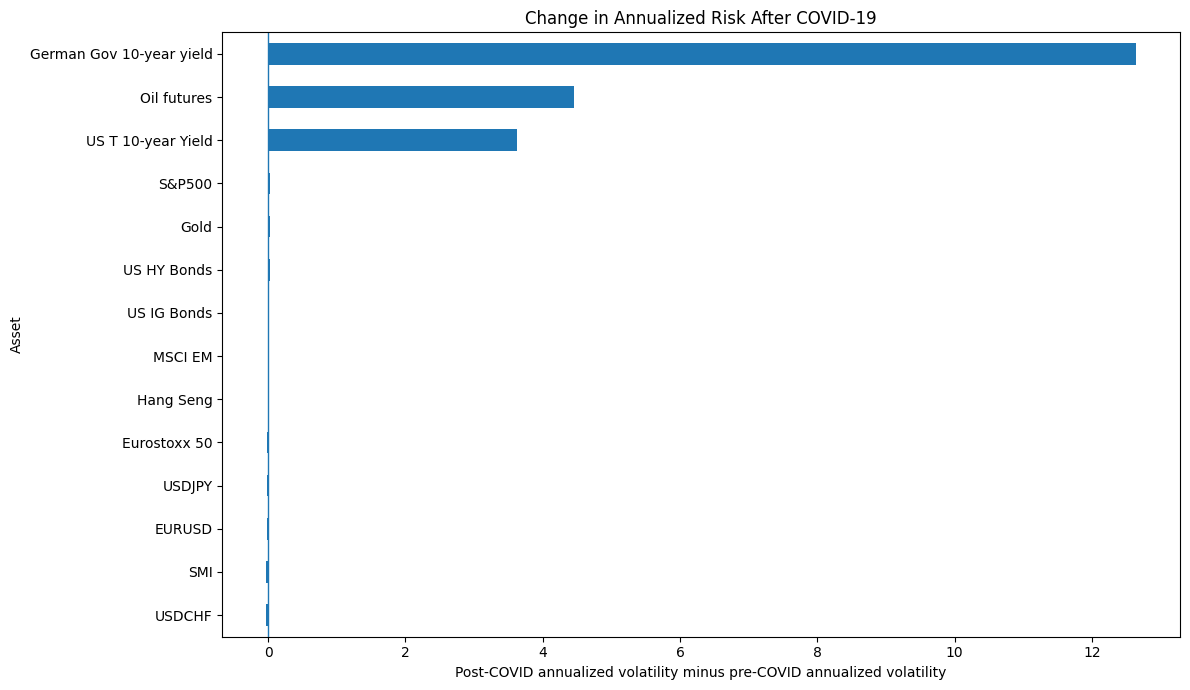

In [80]:
plot_volatility_change(risk_comparison)


### Interpretation

The volatility results suggest that the post-COVID change in risk levels was not uniform across asset classes.

Risk increased particularly for oil futures, government yield changes, credit bonds, gold and the S&P500. This indicates that COVID-19 did not only affect equity risk, but also energy risk, rates risk and credit risk.

However, several assets show lower or broadly stable annualized volatility after COVID-19, including some equity indices and FX rates. Therefore, the evidence does not support the idea that all markets simply became riskier after COVID-19.

The first conclusion is therefore partial: risk levels changed after COVID-19, but the change was selective across asset classes.

### Literature link for correlation and diversification tests

The correlation analysis is motivated by crisis-correlation and contagion research. Longin and Solnik (2001) show that correlations across equity markets can increase in extreme market conditions, while the EMiF course emphasizes that a covariance matrix is the key object behind diversification and portfolio risk. The relevant question is therefore not simply whether each asset became more volatile, but whether cross-asset dependencies changed enough to alter diversification benefits. I use pairwise Fisher tests, block-level averages and a global correlation-matrix distance to separate local pair changes from a system-wide change in co-movement.


## 4. Risk co-movement: correlations and diversification

This section studies whether cross-asset co-movements changed after COVID-19.

Correlation analysis helps answer whether diversification benefits changed. If correlations rise after COVID, assets move more together and diversification becomes less effective. If correlations fall or change selectively, the structure of risk changes in a more nuanced way.

We compute:

1. Pre-COVID correlation matrix.
2. Post-COVID correlation matrix.
3. Difference matrix: post-COVID minus pre-COVID.
4. Average pairwise correlation.
5. Asset-class block correlations.

In [81]:
corr_pre, corr_post, corr_diff = compare_pre_post_correlations(
    pre_covid,
    post_covid,
)

corr_summary = summarize_correlation_change(corr_pre, corr_post)
block_corr_summary = summarize_block_correlations(corr_pre, corr_post)

print("Average correlation summary:")
display(corr_summary.round(4))

print("Block correlation summary:")
display(block_corr_summary.round(4))

Average correlation summary:


,Average_correlation_pre,Average_correlation_post,Change
0,0.1022,0.0842,-0.018


Block correlation summary:


,Correlation_pre,Correlation_post,Change
Block,,,
Equities within,0.4783,0.4550,-0.0233
Yields within,0.5024,0.6553,0.1530
Commodities within,0.1839,-0.0103,-0.1942
FX within,-0.2063,-0.2314,-0.0251
Credit within,0.2503,0.5566,0.3063
Equities vs Yields,0.1620,0.0346,-0.1274
Equities vs Credit,0.1375,0.3142,0.1767
Equities vs Commodities,0.0641,0.0440,-0.0201
Equities vs FX,0.0819,0.0328,-0.0491


In [82]:
print("Pre-COVID correlation matrix:")
display(corr_pre.round(4))

print("Post-COVID correlation matrix:")
display(corr_post.round(4))

print("Correlation difference matrix:")
display(corr_diff.round(4))


Pre-COVID correlation matrix:


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
S&P500,1.0000,0.5332,0.1585,0.4177,0.4633,0.2342,0.1516,0.1363,-0.0461,0.0544,0.2289,-0.1412,0.2633,0.0987
Eurostoxx 50,0.5332,1.0000,0.3622,0.5495,0.8025,0.2220,0.2296,0.1573,-0.0358,-0.0327,0.1925,-0.1315,0.3941,0.1065
Hang Seng,0.1585,0.3622,1.0000,0.6617,0.3349,0.0731,0.0759,0.0782,0.0317,0.0308,0.0489,0.0131,0.2941,0.0115
MSCI EM,0.4177,0.5495,0.6617,1.0000,0.4993,0.1452,0.1624,0.1675,0.1102,0.1283,0.0901,-0.0371,0.4514,-0.0229
SMI,0.4633,0.8025,0.3349,0.4993,1.0000,0.1635,0.1628,0.1062,-0.0647,-0.0623,0.1707,-0.0878,0.3569,0.1857
US T 10-year Yield,0.2342,0.2220,0.0731,0.1452,0.1635,1.0000,0.5024,0.1570,-0.0996,-0.0740,0.2388,-0.8672,-0.0233,0.1504
German Gov 10-year yield,0.1516,0.2296,0.0759,0.1624,0.1628,0.5024,1.0000,0.1253,-0.0666,0.0480,0.1597,-0.5018,0.0566,0.0157
Oil futures,0.1363,0.1573,0.0782,0.1675,0.1062,0.1570,0.1253,1.0000,0.1839,0.0979,0.0651,-0.1140,0.1525,-0.0484
Gold,-0.0461,-0.0358,0.0317,0.1102,-0.0647,-0.0996,-0.0666,0.1839,1.0000,0.3194,-0.2078,0.1135,0.0398,-0.3056
EURUSD,0.0544,-0.0327,0.0308,0.1283,-0.0623,-0.0740,0.0480,0.0979,0.3194,1.0000,-0.3089,0.0846,0.0537,-0.7237


Post-COVID correlation matrix:


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
S&P500,1.0000,0.5476,0.1503,0.3384,0.4544,0.0695,-0.0351,-0.0012,0.1569,0.1972,0.0756,0.1905,0.5878,-0.0636
Eurostoxx 50,0.5476,1.0000,0.3277,0.5053,0.7927,0.0945,0.0623,-0.0663,0.0777,0.2053,0.0363,0.1394,0.5744,-0.0906
Hang Seng,0.1503,0.3277,1.0000,0.8086,0.2303,0.0428,0.0219,-0.0178,0.1332,0.1308,-0.0255,0.0689,0.2998,-0.0908
MSCI EM,0.3384,0.5053,0.8086,1.0000,0.3951,0.0271,0.0029,-0.0276,0.2103,0.2291,-0.0479,0.1649,0.5016,-0.1721
SMI,0.4544,0.7927,0.2303,0.3951,1.0000,0.0522,0.0079,-0.0842,0.0589,0.1190,0.0373,0.1483,0.4666,-0.0479
US T 10-year Yield,0.0695,0.0945,0.0428,0.0271,0.0522,1.0000,0.6553,0.0097,-0.2744,-0.2328,0.4578,-0.8099,-0.1928,0.3498
German Gov 10-year yield,-0.0351,0.0623,0.0219,0.0029,0.0079,0.6553,1.0000,-0.0089,-0.2188,-0.0245,0.3299,-0.6071,-0.2240,0.1711
Oil futures,-0.0012,-0.0663,-0.0178,-0.0276,-0.0842,0.0097,-0.0089,1.0000,-0.0103,0.0006,0.0099,-0.0003,-0.0272,0.0058
Gold,0.1569,0.0777,0.1332,0.2103,0.0589,-0.2744,-0.2188,-0.0103,1.0000,0.3845,-0.3508,0.2772,0.1439,-0.4154
EURUSD,0.1972,0.2053,0.1308,0.2291,0.1190,-0.2328,-0.0245,0.0006,0.3845,1.0000,-0.4999,0.3083,0.3070,-0.7731


Correlation difference matrix:


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
S&P500,0.0000,0.0143,-0.0082,-0.0793,-0.0089,-0.1647,-0.1867,-0.1376,0.2030,0.1428,-0.1533,0.3317,0.3245,-0.1624
Eurostoxx 50,0.0143,0.0000,-0.0346,-0.0442,-0.0098,-0.1275,-0.1673,-0.2236,0.1135,0.2380,-0.1562,0.2709,0.1803,-0.1971
Hang Seng,-0.0082,-0.0346,0.0000,0.1469,-0.1047,-0.0303,-0.0540,-0.0961,0.1015,0.1000,-0.0744,0.0557,0.0058,-0.1023
MSCI EM,-0.0793,-0.0442,0.1469,0.0000,-0.1042,-0.1182,-0.1595,-0.1951,0.1002,0.1007,-0.1379,0.2021,0.0502,-0.1492
SMI,-0.0089,-0.0098,-0.1047,-0.1042,0.0000,-0.1113,-0.1549,-0.1904,0.1236,0.1814,-0.1333,0.2361,0.1097,-0.2336
US T 10-year Yield,-0.1647,-0.1275,-0.0303,-0.1182,-0.1113,0.0000,0.1530,-0.1473,-0.1747,-0.1588,0.2190,0.0573,-0.1695,0.1994
German Gov 10-year yield,-0.1867,-0.1673,-0.0540,-0.1595,-0.1549,0.1530,0.0000,-0.1342,-0.1523,-0.0726,0.1702,-0.1054,-0.2806,0.1554
Oil futures,-0.1376,-0.2236,-0.0961,-0.1951,-0.1904,-0.1473,-0.1342,0.0000,-0.1942,-0.0973,-0.0552,0.1137,-0.1797,0.0542
Gold,0.2030,0.1135,0.1015,0.1002,0.1236,-0.1747,-0.1523,-0.1942,0.0000,0.0651,-0.1429,0.1637,0.1040,-0.1098
EURUSD,0.1428,0.2380,0.1000,0.1007,0.1814,-0.1588,-0.0726,-0.0973,0.0651,0.0000,-0.1910,0.2237,0.2533,-0.0494


## 4.1 Statistical tests for changes in co-movement

This section tests whether key correlations changed statistically, not only visually. For individual pairs, we use the Fisher z-test for equality of correlations. For asset-class blocks, we use bootstrap confidence intervals for the change in average block correlation.


In [83]:
key_pairs = [
    ("S&P500", "US IG Bonds"),
    ("S&P500", "US HY Bonds"),
    ("S&P500", "Gold"),
    ("S&P500", "Oil futures"),
    ("Eurostoxx 50", "S&P500"),
    ("US IG Bonds", "US HY Bonds"),
    ("Gold", "US IG Bonds"),
]

fisher_corr_tests = fisher_correlation_test(pre_covid, post_covid, key_pairs)
display(fisher_corr_tests.round(4))


,Pair,Asset_1,Asset_2,Corr_pre,Corr_post,Change,z_stat,p_value,Economic interpretation
0,S&P500 vs US IG Bonds,S&P500,US IG Bonds,-0.1412,0.1905,0.3317,10.8366,0.0000,significantly increased
1,S&P500 vs US HY Bonds,S&P500,US HY Bonds,0.2633,0.5878,0.3245,13.0923,0.0000,significantly increased
2,S&P500 vs Gold,S&P500,Gold,-0.0461,0.1569,0.2030,6.6096,0.0000,significantly increased
3,S&P500 vs Oil futures,S&P500,Oil futures,0.1363,-0.0012,-0.1376,-4.4778,0.0000,significantly decreased
4,Eurostoxx 50 vs S&P500,Eurostoxx 50,S&P500,0.5332,0.5476,0.0143,0.6554,0.5122,not statistically significant
5,US IG Bonds vs US HY Bonds,US IG Bonds,US HY Bonds,0.2503,0.5566,0.3063,12.0375,0.0000,significantly increased
6,Gold vs US IG Bonds,Gold,US IG Bonds,0.1135,0.2772,0.1637,5.5213,0.0000,significantly increased


In [84]:
equity_assets = ["S&P500", "Eurostoxx 50", "Hang Seng", "MSCI EM", "SMI"]

# These are government bond yield changes, not bond return indices
rates_assets = ["US T 10-year Yield", "German Gov 10-year yield"]

credit_assets = ["US IG Bonds", "US HY Bonds"]
commodity_assets = ["Gold", "Oil futures"]

block_pairs_for_tests = [
    ("Equity-equity", equity_assets, equity_assets),
    ("Equity-rates", equity_assets, rates_assets),
    ("Equity-credit", equity_assets, credit_assets),
    ("Equity-commodity", equity_assets, commodity_assets),
    ("Rates-credit", rates_assets, credit_assets),
]

block_corr_tests = bootstrap_block_correlation_tests(
    pre_covid,
    post_covid,
    block_pairs_for_tests,
    n_bootstrap=N_BOOTSTRAP,
)

display(block_corr_tests.round(4))


,Block pair,Corr_pre,Corr_post,Change,CI_low,CI_high,p_value,Interpretation
0,Equity-equity,0.4783,0.4550,-0.0233,-0.0861,0.0371,0.4933,not statistically significant
1,Equity-rates,0.1620,0.0346,-0.1274,-0.1794,-0.0744,0.0000,significantly decreased
2,Equity-credit,0.1375,0.3142,0.1767,0.1050,0.2566,0.0000,significantly increased
3,Equity-commodity,0.0641,0.0440,-0.0201,-0.0781,0.0718,0.5733,not statistically significant
4,Rates-credit,-0.3339,-0.4585,-0.1246,-0.1864,-0.0615,0.0000,significantly decreased


In this section, “rates” refers to daily changes in government bond yields, while “credit” refers to the US investment-grade and high-yield bond index series. This avoids comparing yield changes and bond-index returns as if they were the same object.

In [85]:
block_changes = block_corr_summary["Change"].sort_values(ascending=False)

print("Largest increases in block correlations:")
display(block_changes.head(5).round(4))

print("Largest decreases in block correlations:")
display(block_changes.tail(5).round(4))

Largest increases in block correlations:


Block
Credit within              0.3063
Equities vs Credit         0.1767
Yields within              0.1530
Equities vs Commodities   -0.0201
Equities within           -0.0233
Name: Change, dtype: float64

Largest decreases in block correlations:


Block
FX within            -0.0251
Equities vs FX       -0.0491
Credit vs Yields     -0.1246
Equities vs Yields   -0.1274
Commodities within   -0.1942
Name: Change, dtype: float64

### Figures: correlation changes

The first figure shows changes in asset-class block correlations. The second figure shows the full correlation difference matrix, where each cell is post-COVID correlation minus pre-COVID correlation.

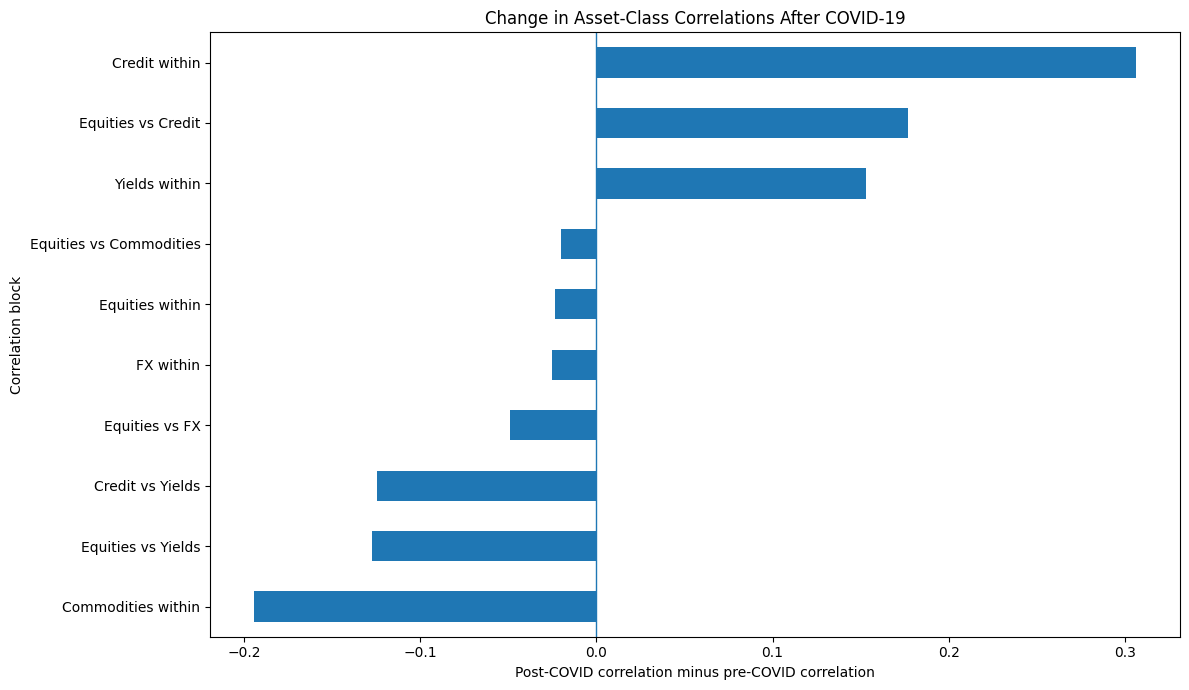

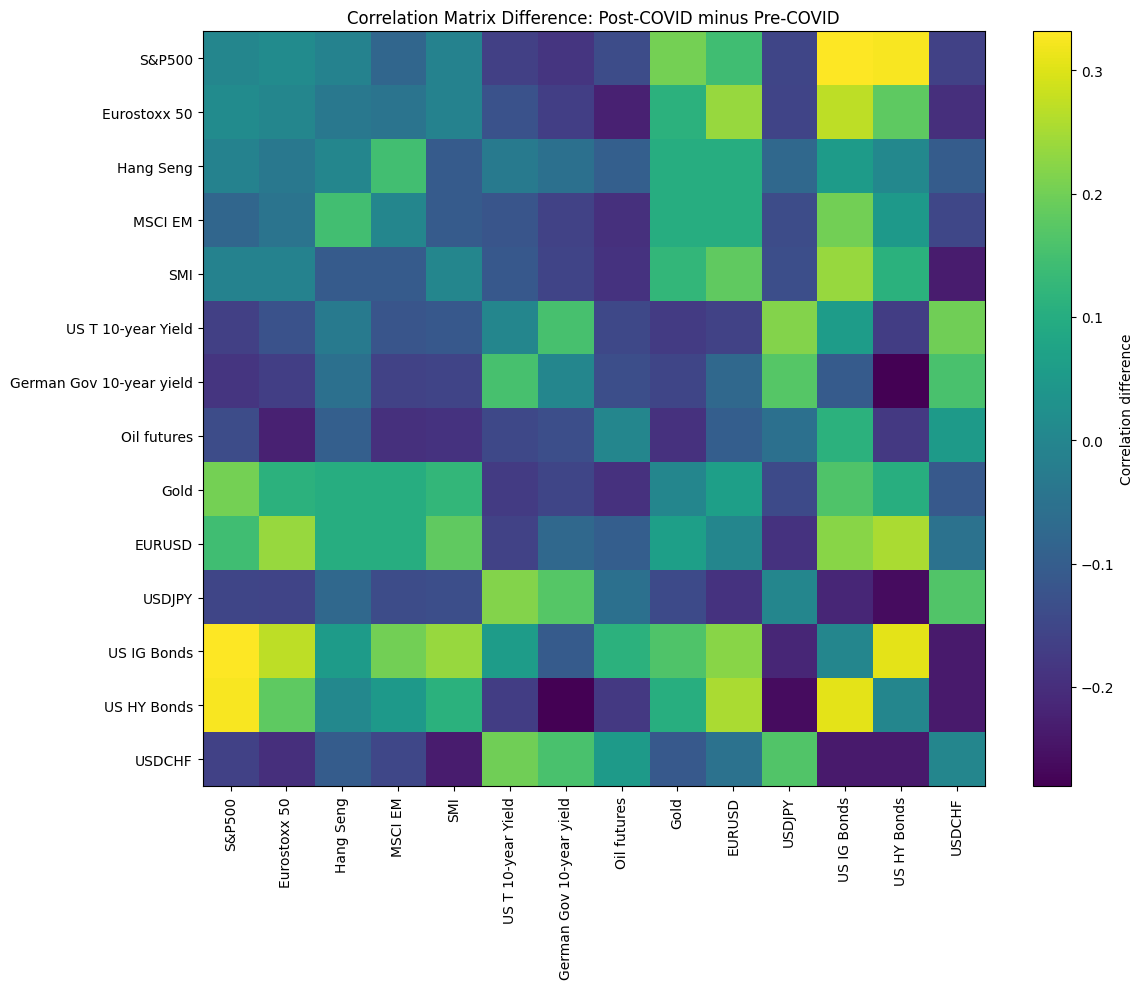

In [86]:
plot_block_correlation_change(block_corr_summary)
plot_correlation_difference_heatmap(corr_diff)


### Interpretation

The correlation results do not show a generalized increase in cross-asset correlations after COVID-19. The average pairwise correlation slightly declined after COVID.

However, the block-level results show important changes in the internal structure of co-movements. Credit markets became much more internally correlated, and the correlation between equities and credit increased strongly. This suggests that credit risk became more closely connected to broader risk-asset dynamics after COVID.

Government yield changes also became more synchronized, suggesting a stronger global rates or inflation channel. At the same time, equity-yield correlations declined, and commodity co-movement weakened.

Therefore, COVID-19 did not simply make all assets move together. Instead, it changed the correlation structure selectively, especially through credit and rates channels. This is important for portfolio management because diversification benefits changed across asset classes.

## 4.2 Global correlation-matrix change test

Pairwise correlations only show local changes. To test whether the overall co-movement structure changed, we compute the Frobenius norm of the difference between the post-COVID and pre-COVID correlation matrices.

This is preferred to a raw covariance-matrix distance in the main analysis because the dataset combines log returns, yield changes in basis points and a transformed oil series. Correlations are unit-free, so the global test is not mechanically dominated by variables measured in larger units.


In [87]:
correlation_matrix_distance = correlation_frobenius_test(
    pre_covid,
    post_covid,
    n_bootstrap=N_BOOTSTRAP,
)

display(correlation_matrix_distance.round(6))


,Metric,Value,CI_low,CI_high,Interpretation
0,Frobenius norm of correlation-matrix difference,2.178687,1.936042,2.622053,unit-free global measure of cross-asset correl...


### Literature link for PCA and common risk factors

PCA is used here as a reduced-form factor model. In the EMiF logic, a large first principal component indicates that a large part of the standardized return covariance matrix can be summarized by one common shock. If the first components explain more variance after COVID, risk is more concentrated and diversification is less effective because assets are moving together through common drivers. This section therefore tests the **factor-concentration hypothesis** rather than trying to label each principal component as a structural macro factor.


## 5. Risk factors: Principal Component Analysis

This section studies whether financial market risk became more concentrated in a smaller number of common factors after COVID-19.

Principal Component Analysis (PCA) transforms the cross-section of asset returns into orthogonal components. If the first principal components explain more variance after COVID, it means that a larger share of market risk is driven by common shocks.

To avoid high-volatility assets mechanically dominating the PCA, the analysis is performed on standardized returns.

In [88]:
explained_pre, explained_post, pca_comparison, loadings_pre, loadings_post = (
    compare_pre_post_pca(pre_covid, post_covid)
)

print("PCA explained variance comparison:")
display(pca_comparison.head(10).round(4))

PCA explained variance comparison:


,Explained_pre,Explained_post,Change
PC1,0.2581,0.2946,0.0365
PC2,0.1764,0.2086,0.0322
PC3,0.1387,0.1123,-0.0264
PC4,0.0728,0.0863,0.0135
PC5,0.0682,0.0720,0.0038
PC6,0.0561,0.0537,-0.0023
PC7,0.0503,0.0468,-0.0035
PC8,0.0475,0.0323,-0.0152
PC9,0.0395,0.0271,-0.0124
PC10,0.0350,0.0213,-0.0137


In [89]:
pc12_pre = pca_comparison.loc[["PC1", "PC2"], "Explained_pre"].sum()
pc12_post = pca_comparison.loc[["PC1", "PC2"], "Explained_post"].sum()
pc12_change = pc12_post - pc12_pre

print(f"PC1 + PC2 explained variance pre-COVID:  {pc12_pre:.4f}")
print(f"PC1 + PC2 explained variance post-COVID: {pc12_post:.4f}")
print(f"Change: {pc12_change:.4f}")

PC1 + PC2 explained variance pre-COVID:  0.4345
PC1 + PC2 explained variance post-COVID: 0.5032
Change: 0.0687


In [90]:
print("PC1 loadings pre-COVID:")
display(loadings_pre["PC1"].sort_values(ascending=False).round(4))

print("PC1 loadings post-COVID:")
display(loadings_post["PC1"].sort_values(ascending=False).round(4))

PC1 loadings pre-COVID:


US IG Bonds                 0.2004
EURUSD                      0.0539
Gold                        0.0526
USDCHF                     -0.1354
Oil futures                -0.1401
USDJPY                     -0.2062
German Gov 10-year yield   -0.2304
US HY Bonds                -0.2493
US T 10-year Yield         -0.2685
Hang Seng                  -0.2768
S&P500                     -0.3408
MSCI EM                    -0.3780
SMI                        -0.4043
Eurostoxx 50               -0.4328
Name: PC1, dtype: float64

PC1 loadings post-COVID:


USDCHF                      0.3037
USDJPY                      0.2500
US T 10-year Yield          0.2483
German Gov 10-year yield    0.2041
Oil futures                 0.0219
Hang Seng                  -0.2074
Gold                       -0.2432
SMI                        -0.2446
S&P500                     -0.2458
Eurostoxx 50               -0.2790
MSCI EM                    -0.2918
EURUSD                     -0.3094
US IG Bonds                -0.3509
US HY Bonds                -0.3705
Name: PC1, dtype: float64

In [91]:
print("PCA explained variance before COVID:")
display(explained_pre.round(4))

print("PCA explained variance after COVID:")
display(explained_post.round(4))

print("PCA loadings before COVID:")
display(loadings_pre.round(4))

print("PCA loadings after COVID:")
display(loadings_post.round(4))


PCA explained variance before COVID:


,Eigenvalue,Explained_variance_ratio,Cumulative_explained_variance
PC1,3.6136,0.2581,0.2581
PC2,2.4691,0.1764,0.4345
PC3,1.9411,0.1387,0.5731
PC4,1.0189,0.0728,0.6459
PC5,0.9547,0.0682,0.7141
PC6,0.7850,0.0561,0.7702
PC7,0.7043,0.0503,0.8205
PC8,0.6653,0.0475,0.8680
PC9,0.5531,0.0395,0.9075
PC10,0.4905,0.0350,0.9425


PCA explained variance after COVID:


,Eigenvalue,Explained_variance_ratio,Cumulative_explained_variance
PC1,4.1248,0.2946,0.2946
PC2,2.9199,0.2086,0.5032
PC3,1.5721,0.1123,0.6155
PC4,1.2075,0.0863,0.7017
PC5,1.0083,0.0720,0.7738
PC6,0.7523,0.0537,0.8275
PC7,0.6547,0.0468,0.8743
PC8,0.4519,0.0323,0.9065
PC9,0.3791,0.0271,0.9336
PC10,0.2983,0.0213,0.9549


PCA loadings before COVID:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
S&P500,-0.3408,-0.0598,0.0146,0.0300,-0.4876,-0.0811,-0.3076,-0.2959,-0.3513,0.5110,0.1674,-0.1635,0.1086,-0.0399
Eurostoxx 50,-0.4328,-0.1222,0.0800,-0.0754,-0.2502,-0.2091,0.1584,0.1047,0.2273,-0.1783,0.2758,0.0793,-0.6910,0.0039
Hang Seng,-0.2768,-0.2215,0.0715,-0.2199,0.6533,-0.0168,-0.0782,-0.2538,0.1070,0.0572,0.2341,-0.5017,0.0130,-0.0437
MSCI EM,-0.3780,-0.2718,0.0125,-0.1029,0.3146,-0.0064,-0.1360,-0.1193,-0.0842,0.1441,-0.3224,0.7113,0.0246,0.0488
SMI,-0.4043,-0.1083,0.1447,-0.1052,-0.2510,-0.2859,0.2128,0.1328,0.2870,-0.2614,-0.2199,-0.1381,0.6052,0.0276
US T 10-year Yield,-0.2685,0.3418,-0.3845,-0.0348,0.0884,-0.0370,-0.0325,-0.0009,-0.3494,-0.2855,0.0150,-0.0784,-0.0020,0.6647
German Gov 10-year yield,-0.2304,0.1919,-0.3553,-0.0998,0.0399,0.3451,0.1752,0.4406,0.3442,0.5528,0.0172,-0.0318,0.0422,0.0350
Oil futures,-0.1401,-0.0768,-0.1949,0.7724,0.0778,0.0324,0.4219,-0.3732,0.1130,0.0482,-0.0020,-0.0028,0.0204,0.0020
Gold,0.0526,-0.2962,-0.2450,0.4009,0.1459,-0.4623,-0.4203,0.5164,-0.0130,0.0410,0.0597,-0.0680,0.0174,-0.0107
EURUSD,0.0539,-0.3818,-0.4295,-0.1238,-0.2139,0.2082,-0.1650,-0.1718,0.1295,-0.1295,-0.5706,-0.2993,-0.2381,-0.0158


PCA loadings after COVID:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
S&P500,-0.2458,-0.2791,-0.1436,-0.3139,-0.1514,-0.3328,-0.4482,0.2788,0.1919,-0.5167,0.1608,0.0079,0.0202,0.0125
Eurostoxx 50,-0.2790,-0.3808,-0.0759,-0.2127,0.0282,0.0943,0.3363,-0.0417,0.0069,0.0095,-0.3015,-0.7004,0.0792,0.1176
Hang Seng,-0.2074,-0.2499,0.1695,0.6550,0.0330,0.0683,-0.0212,0.0211,0.0854,-0.1863,-0.0237,0.0731,0.6174,-0.0326
MSCI EM,-0.2918,-0.2968,0.1325,0.4763,0.0091,0.0143,-0.0551,0.0055,0.0145,0.0144,0.0813,-0.0147,-0.7533,0.0657
SMI,-0.2446,-0.3393,-0.1462,-0.2508,0.0790,0.0962,0.5793,-0.0899,0.0619,-0.0424,0.2280,0.5641,0.0114,-0.0748
US T 10-year Yield,0.2483,-0.3849,0.2974,-0.1160,-0.0441,-0.0741,-0.0843,0.3248,0.0936,0.4451,0.0115,0.1513,0.0996,0.5731
German Gov 10-year yield,0.2041,-0.2929,0.4300,-0.1671,-0.0057,0.1330,-0.1128,-0.2880,-0.6551,-0.2878,0.1765,-0.0299,0.0124,-0.0461
Oil futures,0.0219,0.0335,0.0156,0.0686,-0.9780,0.0592,0.1807,-0.0138,-0.0190,0.0047,0.0075,0.0007,-0.0003,-0.0152
Gold,-0.2432,0.1431,0.2346,0.0315,0.0017,-0.8495,0.2212,-0.1156,-0.2276,0.1534,-0.0338,0.0011,0.0593,-0.0174
EURUSD,-0.3094,0.1213,0.4527,-0.2353,-0.0397,0.1617,-0.1690,-0.2066,0.2081,-0.0730,-0.6251,0.2967,-0.0534,0.0093


### Bootstrap inference for PCA concentration

The PCA comparison is strengthened with bootstrap confidence intervals for the increase in common-factor concentration. If PC1 or PC1+PC2 increases significantly, risk became more concentrated in common shocks and diversification may have weakened.


In [92]:
pca_bootstrap_tests = bootstrap_pca_concentration(
    pre_covid,
    post_covid,
    n_bootstrap=N_BOOTSTRAP,
)

display(pca_bootstrap_tests.round(4))


,PCA metric,Pre,Post,Change,CI_low,CI_high,p_value,Interpretation
0,PC1 explained variance,0.2581,0.2946,0.0365,0.0125,0.0662,0.0,significantly increased
1,PC1 + PC2 explained variance,0.4345,0.5032,0.0687,0.0449,0.0942,0.0,significantly increased


### Moving-block bootstrap robustness for PCA concentration

The previous bootstrap resamples individual days independently. That is useful, but financial returns display volatility clustering, so an iid bootstrap can understate dependence in the data-generating process. To align the inference more closely with the EMiF discussion of volatility clustering and persistent risk, we add a moving-block bootstrap.

The idea is to resample short contiguous blocks of observations instead of isolated days. This preserves part of the local time-series dependence while still generating many pseudo-samples. If the PCA concentration result survives this check, the conclusion that common risk factors became more important after COVID is more credible.

In [93]:
# ============================================================
# Moving-block bootstrap robustness for PCA concentration
# ============================================================

def moving_block_resample_rows(df, rng, block_length=20):
    """
    Resample rows using overlapping moving blocks.

    This is a simple dependence-aware bootstrap. It is useful for financial returns
    because volatility clustering makes iid resampling too optimistic in some cases.
    """
    clean = df.dropna().copy()
    n = len(clean)

    if n == 0:
        return clean

    if n <= block_length:
        return clean.sample(n=n, replace=True, random_state=int(rng.integers(0, 1_000_000)))

    starts = np.arange(0, n - block_length + 1)
    selected_blocks = []

    while sum(len(block) for block in selected_blocks) < n:
        start = int(rng.choice(starts))
        selected_blocks.append(clean.iloc[start:start + block_length])

    resampled = pd.concat(selected_blocks, axis=0).iloc[:n].reset_index(drop=True)
    return resampled


def block_bootstrap_pca_concentration(pre_df, post_df, n_bootstrap=200, block_length=20):
    """
    Moving-block bootstrap for the change in PC1 and PC1+PC2 explained variance.
    """
    pre_pc1, pre_pc12 = pca_concentration_metrics(pre_df)
    post_pc1, post_pc12 = pca_concentration_metrics(post_df)

    rng = np.random.default_rng(RANDOM_SEED)
    pc1_changes = []
    pc12_changes = []

    for _ in range(n_bootstrap):
        pre_b = moving_block_resample_rows(pre_df, rng, block_length=block_length)
        post_b = moving_block_resample_rows(post_df, rng, block_length=block_length)

        pre_b_pc1, pre_b_pc12 = pca_concentration_metrics(pre_b)
        post_b_pc1, post_b_pc12 = pca_concentration_metrics(post_b)

        pc1_changes.append(post_b_pc1 - pre_b_pc1)
        pc12_changes.append(post_b_pc12 - pre_b_pc12)

    rows = []
    for metric, pre_value, post_value, boot_changes in [
        ("PC1 explained variance", pre_pc1, post_pc1, np.asarray(pc1_changes)),
        ("PC1 + PC2 explained variance", pre_pc12, post_pc12, np.asarray(pc12_changes)),
    ]:
        change = post_value - pre_value
        ci_low, ci_high = np.nanpercentile(boot_changes, [2.5, 97.5])
        p_value = min(1.0, 2.0 * min(np.nanmean(boot_changes <= 0), np.nanmean(boot_changes >= 0)))

        rows.append(
            {
                "PCA metric": metric,
                "Pre": pre_value,
                "Post": post_value,
                "Change": change,
                "Block_CI_low": ci_low,
                "Block_CI_high": ci_high,
                "Block_p_value": p_value,
                "Interpretation": classify_change(change, p_value, "increased", "decreased"),
            }
        )

    return pd.DataFrame(rows)


pca_block_bootstrap_tests = block_bootstrap_pca_concentration(
    pre_covid,
    post_covid,
    n_bootstrap=200,
    block_length=20,
)

display(pca_block_bootstrap_tests.round(4))

,PCA metric,Pre,Post,Change,Block_CI_low,Block_CI_high,Block_p_value,Interpretation
0,PC1 explained variance,0.2581,0.2946,0.0365,0.0025,0.0664,0.03,significantly increased
1,PC1 + PC2 explained variance,0.4345,0.5032,0.0687,0.0264,0.0883,0.00,significantly increased


### Figure: PCA explained variance

The following figure compares the variance explained by the first principal components before and after COVID-19.

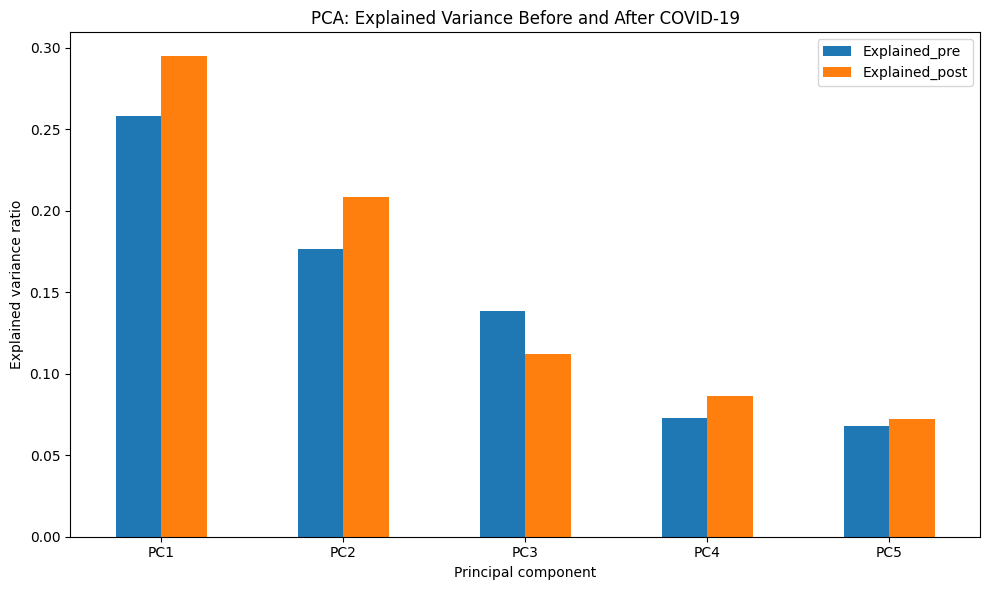

In [94]:
plot_pca_explained_variance(pca_comparison)


### Interpretation

The PCA results show that risk became more concentrated after COVID-19.

The first principal component explains a larger share of total standardized variance after COVID. More importantly, the first two principal components together explain about 50% of total variance post-COVID, compared with about 43% before COVID.

This suggests that post-COVID market risk was more driven by common cross-asset factors. The loadings also indicate that the post-COVID first component is broader, involving equities, credit, FX, yields and gold. This supports the idea that risk shifted from a mainly equity-driven global risk factor toward a more integrated macro-financial risk factor.

This is one of the strongest pieces of evidence that the structure of risk changed after COVID-19.

### Literature link for regimes and structural breaks

A regime change means more than a temporary crisis spike: it means that parameters such as volatility or correlations behave differently for a sustained period. This section is motivated by the structural-break literature of Chow (1960), Andrews (1993), and Bai and Perron (1998, 2003), and by the EMiF course material on regime shifts, structural breaks and the portfolio consequences of an unstable covariance matrix. Rolling estimates are not formal proof of a break, but they help visualize whether the post-COVID period looks like a persistent change rather than a one-day shock.


## 6. Risk regimes: rolling volatility and rolling correlations

The previous sections compared pre-COVID and post-COVID averages. This section adds a dynamic view by computing rolling indicators.

We use a 252-day rolling window, which approximately corresponds to one trading year.

The objective is to observe whether COVID-19 coincides with a visible change in market risk regimes, especially in volatility and cross-asset correlation.

In [ ]:
rolling_vol = compute_rolling_volatility(
    returns_df,
    window=252,
)

rolling_corr = compute_rolling_average_correlation(
    returns_df,
    window=252,
)

print("Rolling volatility shape:", rolling_vol.shape)
print("Rolling correlation length:", len(rolling_corr))

Rolling volatility shape: (7332, 14)
Rolling correlation length: 7081


,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,0.174050,0.161346,0.199940,0.171371,0.135898,73.619483,62.628653,0.451892,0.247368,0.078124,0.095751,0.041365,0.030944,0.094021
2026-04-21,0.174100,0.161457,0.199156,0.171548,0.136193,73.653266,62.638675,0.452599,0.248353,0.078207,0.095593,0.041454,0.030988,0.094092
2026-04-22,0.174315,0.161512,0.199563,0.171666,0.136228,73.579236,62.615954,0.452488,0.248366,0.078303,0.095550,0.041393,0.030979,0.094241
2026-04-23,0.174345,0.161530,0.199147,0.171666,0.136880,73.596719,62.594064,0.453416,0.248560,0.077996,0.095562,0.041405,0.031001,0.094279
2026-04-24,0.173826,0.161420,0.199083,0.171698,0.136644,73.140745,62.490503,0.453205,0.248283,0.078041,0.095106,0.041143,0.031001,0.094215


### Figure: rolling annualized volatility

The following figure shows rolling annualized volatility for selected assets. The vertical dashed line marks 11 March 2020.

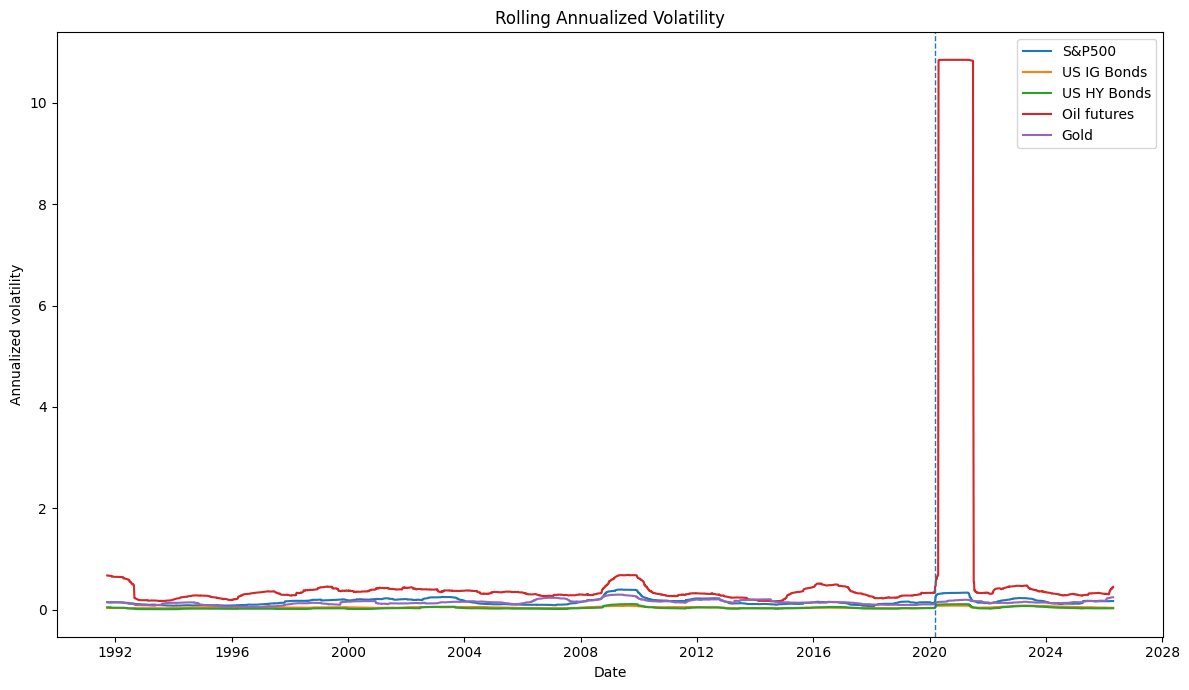

In [97]:
selected_assets = [
    "S&P500",
    "US IG Bonds",
    "US HY Bonds",
    "Oil futures",
    "Gold",
]

plot_rolling_volatility(rolling_vol, selected_assets)


### Figure: rolling average cross-asset correlation

The following figure shows the rolling average pairwise correlation across all assets. This helps assess whether cross-asset diversification changed dynamically around COVID-19.

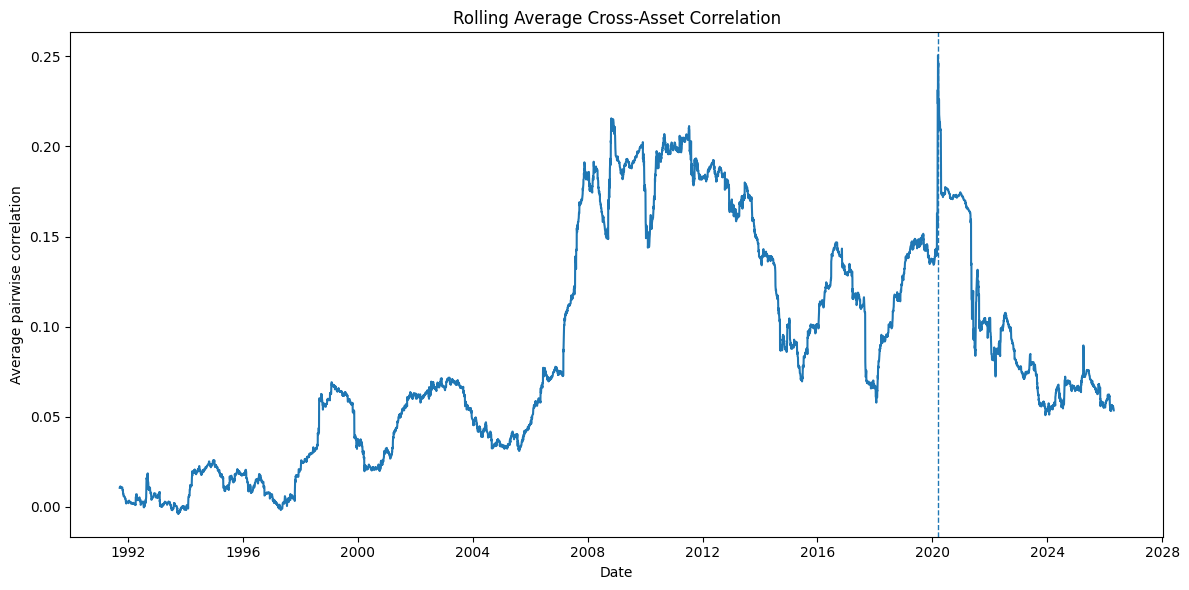

In [98]:
plot_rolling_average_correlation(rolling_corr)


### Interpretation

The rolling volatility figure shows that COVID-19 coincided with a sharp increase in risk for several assets, especially oil, equities and credit-related instruments. This confirms that the pandemic period was associated with a clear risk-regime shock.

The rolling average correlation figure provides a dynamic view of diversification. If the average correlation rises during stress periods, diversification becomes less effective. If it later declines, the shock may be more temporary. This helps distinguish between a short-lived crisis episode and a more persistent change in the risk structure.

Overall, the rolling evidence supports the idea that COVID-19 was a major risk-regime event. Combined with the pre/post tables, it suggests that the risk structure changed selectively rather than uniformly.

## 6.1 Structural-break analysis: equity-bond diversification regime

The rolling figures are descriptive. To add a formal regime/break dimension from the course, we focus on the 252-day rolling correlation between the S&P 500 and US investment-grade bonds. This is economically important because equity-bond diversification is central to portfolio construction.

We estimate a Bai-Perron-style segmented mean-break model by dynamic programming. The objective is to identify persistent shifts in the average rolling correlation. Higher or positive equity-bond correlation means weaker diversification; lower or negative correlation means stronger diversification.


In [99]:
rolling_spx_ig_corr = compute_rolling_pair_correlation(
    returns_df,
    "S&P500",
    "US IG Bonds",
    window=252,
)

spx_ig_break_segments = segmented_mean_breaks(
    rolling_spx_ig_corr,
    max_breaks=3,
    min_segment=126,
)

print("Rolling S&P500 vs US IG Bonds correlation, last observations:")
display(rolling_spx_ig_corr.tail().round(4))

print("Detected correlation-regime segments:")
display(spx_ig_break_segments)


Rolling S&P500 vs US IG Bonds correlation, last observations:


Date
2026-04-20    0.1373
2026-04-21    0.1415
2026-04-22    0.1447
2026-04-23    0.1466
2026-04-24    0.1587
Name: S&P500 vs US IG Bonds, dtype: float64

Detected correlation-regime segments:


,Segment,Start,End,Avg correlation,Observations,Interpretation
0,1,1991-09-19,1998-01-26,0.425610,1197,higher values mean weaker equity-bond diversif...
1,2,1998-01-27,2007-10-03,-0.082900,2016,negative values mean stronger equity-bond dive...
2,3,2007-10-04,2020-03-16,-0.297650,2604,negative values mean stronger equity-bond dive...
3,4,2020-03-17,2026-04-24,0.157753,1264,higher values mean weaker equity-bond diversif...


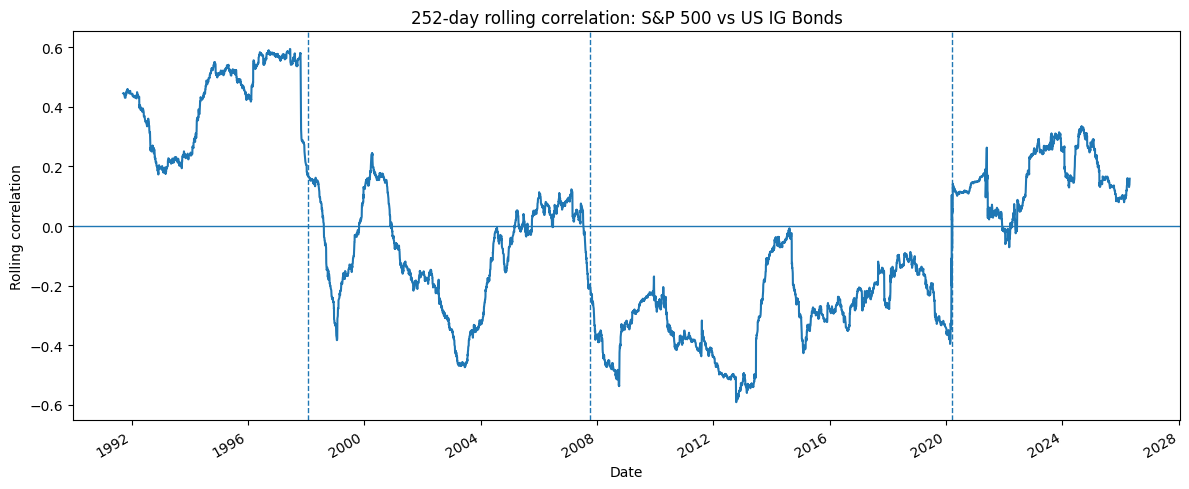

In [100]:
plt.figure(figsize=(12, 5))
rolling_spx_ig_corr.plot()
for break_date in spx_ig_break_segments["Start"].iloc[1:]:
    plt.axvline(break_date, linestyle="--", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("252-day rolling correlation: S&P 500 vs US IG Bonds")
plt.ylabel("Rolling correlation")
plt.tight_layout()
plt.show()


### Literature link for portfolio implications

The portfolio section connects the econometric results to the economic meaning of risk structure. In Markowitz (1952), the covariance matrix is the central input for optimal diversification. In equal-risk-contribution portfolio construction, as formalized by Maillard, Roncalli and Teiletche (2010), portfolio weights are chosen so that assets contribute equally to total portfolio risk. If the post-COVID covariance matrix changed, optimal diversification and risk budgeting should also change. This is why portfolio weights are used as an economic diagnostic, not as a trading recommendation.


## 6.2 Portfolio implications: did diversification change?

The final empirical question is whether the change in risk structure matters for a portfolio manager. We compare an equal-weight portfolio, a long-only minimum-variance portfolio and an equal-risk-contribution portfolio.

For this section, the analysis is restricted to return-like investable series only. Government yield changes are excluded because they are measured in basis points and are not directly investable returns. Oil is excluded from the baseline portfolio exercise because its post-COVID transformation is dominated by the April 2020 negative-price episode. Oil and yield changes remain included in the broader risk-structure, PCA, correlation and robustness analyses.

The first table asks: if an investor kept the same pre-COVID allocation, did realized portfolio risk and diversification change under the post-COVID covariance matrix? The second table asks: if the investor recalibrated the allocation separately before and after COVID, how would optimal weights change?


In [101]:
pre_portfolio = pre_covid[INVESTABLE_RETURN_ASSETS].copy()
post_portfolio = post_covid[INVESTABLE_RETURN_ASSETS].copy()

portfolio_summary, portfolio_weights, portfolio_risk_contributions = portfolio_implication_tables(
    pre_portfolio,
    post_portfolio,
)

print("Portfolio analysis using investable return-like assets only:")
display(portfolio_summary.round(4))

print("Pre/post optimal weights:")
display(portfolio_weights.round(4))

print("Portfolio risk contributions:")
display(portfolio_risk_contributions.round(4))


Portfolio analysis using investable return-like assets only:


,Portfolio,Pre vol,Post vol using same weights,Vol change,Pre diversification ratio,Post diversification ratio using same weights,Interpretation
0,Equal weight,0.0744,0.0762,0.0019,1.8809,1.8204,tests whether the same allocation became riski...
1,Minimum variance,0.0251,0.0317,0.0067,2.9427,2.3264,tests whether the same allocation became riski...
2,Equal risk contribution,0.0435,0.0448,0.0013,2.6021,2.3980,tests whether the same allocation became riski...


Pre/post optimal weights:


,Asset,Min-var weight pre,Min-var weight post,ERC weight pre,ERC weight post
0,S&P500,0.0000,0.0000,0.0429,0.0353
1,Eurostoxx 50,0.0000,0.0000,0.0317,0.0339
2,Hang Seng,0.0000,0.0000,0.0343,0.0379
3,MSCI EM,0.0000,0.0000,0.0345,0.0390
4,SMI,0.0000,0.0000,0.0389,0.0512
5,Gold,0.0202,0.0198,0.0942,0.0704
6,EURUSD,0.2144,0.3552,0.2262,0.1692
7,USDJPY,0.0559,0.0917,0.1084,0.2663
8,USDCHF,0.1835,0.3463,0.1910,0.0001
9,US IG Bonds,0.2738,0.1846,0.0001,0.1890


Portfolio risk contributions:


,Portfolio,Asset,Risk contribution pre,Risk contribution post using same weights,Change
0,Equal weight,S&P500,0.1339,0.1684,0.0345
1,Equal weight,Eurostoxx 50,0.2051,0.1888,-0.0164
2,Equal weight,Hang Seng,0.2013,0.1871,-0.0142
3,Equal weight,MSCI EM,0.1794,0.1685,-0.0108
4,Equal weight,SMI,0.1632,0.1241,-0.0391
5,Equal weight,Gold,0.0321,0.0750,0.0429
6,Equal weight,EURUSD,0.0087,0.0266,0.0179
7,Equal weight,USDJPY,0.0350,0.0025,-0.0325
8,Equal weight,USDCHF,0.0176,-0.0146,-0.0322
9,Equal weight,US IG Bonds,-0.0017,0.0221,0.0238


The portfolio weights confirm that the post-COVID change in the covariance matrix is economically relevant. The long-only minimum-variance portfolio is highly concentrated in low-risk and diversifying assets and allocates almost no weight to equities, which is expected because the objective ignores expected returns and only minimizes variance. More importantly, the optimal weights change substantially after COVID: the minimum-variance allocation shifts away from US high-yield bonds and toward currency exposures, while the ERC allocation changes its main risk-balancing assets. This shows that the post-COVID change in risk structure is not only visible in volatility and correlation statistics; it also changes portfolio construction.

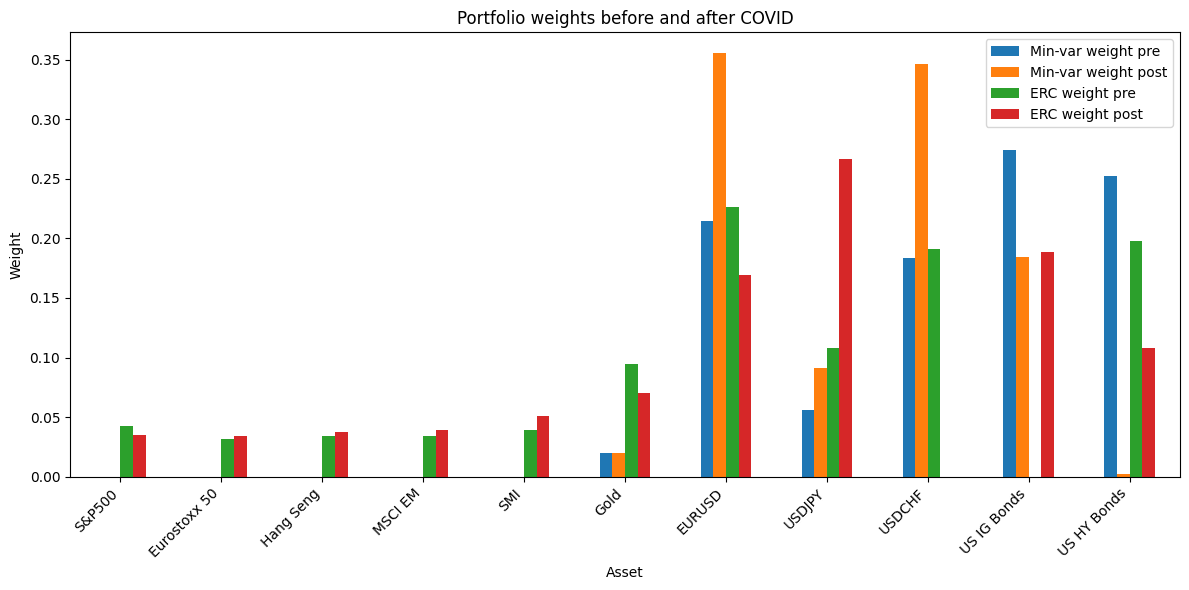

In [102]:
minvar_erc_weights = portfolio_weights.set_index("Asset")[[
    "Min-var weight pre",
    "Min-var weight post",
    "ERC weight pre",
    "ERC weight post",
]]

minvar_erc_weights.plot(kind="bar", figsize=(12, 6))
plt.title("Portfolio weights before and after COVID")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6.3 Dynamic covariance robustness: EWMA risk structure

The previous sections compare pre-COVID and post-COVID unconditional covariance matrices. We also estimate a dynamic covariance matrix using an EWMA filter.

The EWMA covariance recursion is:

\[
\Sigma_t = \lambda \Sigma_{t-1} + (1-\lambda) r_{t-1} r_{t-1}'
\]

with \(\lambda = 0.94\), a standard daily-data choice. This gives more weight to recent observations and allows the covariance matrix to evolve through time. We then compare the pre- and post-COVID average EWMA correlation, equal-weight portfolio volatility, and diversification ratio.

EWMA dynamic covariance robustness:


,Pre-COVID EWMA average,Post-COVID EWMA average,Change
EWMA_average_correlation,0.1116,0.1295,0.0179
EWMA_equal_weight_vol,0.0664,0.0693,0.0029
EWMA_diversification_ratio,1.9999,1.9456,-0.0544


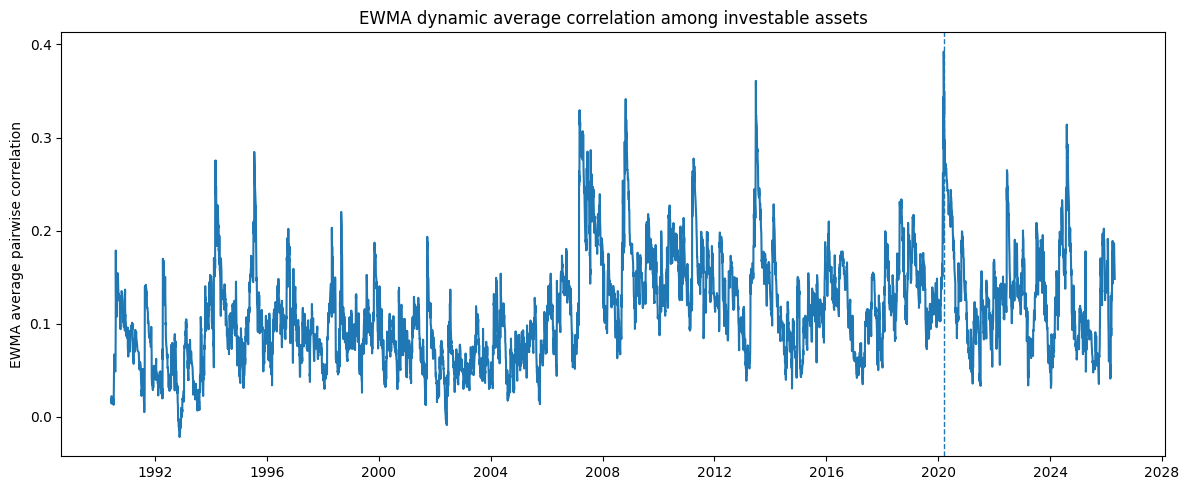

In [117]:
# ============================================================
# EWMA dynamic covariance robustness
# ============================================================

def ewma_dynamic_risk_summary(returns_df, assets, lam=0.94, annualization=252):
    """
    Compute EWMA covariance matrices and summarize their portfolio implications.
    """
    data = returns_df[assets].dropna().copy()
    values = data.values
    n_assets = len(assets)

    if len(data) < 60:
        raise ValueError("Not enough observations for EWMA covariance estimation.")

    # Initialize with the first 60 observations.
    sigma = np.cov(values[:60].T)
    weights = np.repeat(1 / n_assets, n_assets)

    rows = []
    for t in range(60, len(data)):
        r_lag = values[t - 1].reshape(-1, 1)
        sigma = lam * sigma + (1 - lam) * (r_lag @ r_lag.T)

        vols = np.sqrt(np.diag(sigma))
        corr = sigma / np.outer(vols, vols)
        avg_corr = average_pairwise_correlation(pd.DataFrame(corr, index=assets, columns=assets))

        portfolio_vol = float(np.sqrt(weights @ sigma @ weights) * np.sqrt(annualization))
        weighted_asset_vol = float(weights @ (vols * np.sqrt(annualization)))
        diversification_ratio = weighted_asset_vol / portfolio_vol if portfolio_vol > 0 else np.nan

        rows.append(
            {
                "Date": data.index[t],
                "EWMA_average_correlation": avg_corr,
                "EWMA_equal_weight_vol": portfolio_vol,
                "EWMA_diversification_ratio": diversification_ratio,
            }
        )

    return pd.DataFrame(rows).set_index("Date")


ewma_risk = ewma_dynamic_risk_summary(
    returns_df,
    assets=INVESTABLE_RETURN_ASSETS,
    lam=0.94,
)

COVID_BREAKPOINT = pd.to_datetime("2020-03-11")

ewma_pre = ewma_risk.loc[ewma_risk.index < COVID_BREAKPOINT]
ewma_post = ewma_risk.loc[ewma_risk.index >= COVID_BREAKPOINT]

ewma_summary = pd.DataFrame(
    {
        "Pre-COVID EWMA average": ewma_pre.mean(),
        "Post-COVID EWMA average": ewma_post.mean(),
    }
)
ewma_summary["Change"] = ewma_summary["Post-COVID EWMA average"] - ewma_summary["Pre-COVID EWMA average"]

print("EWMA dynamic covariance robustness:")
display(ewma_summary.round(4))

plt.figure(figsize=(12, 5))
plt.plot(ewma_risk.index, ewma_risk["EWMA_average_correlation"])
plt.axvline(COVID_BREAKPOINT, linestyle="--", linewidth=1)
plt.title("EWMA dynamic average correlation among investable assets")
plt.ylabel("EWMA average pairwise correlation")
plt.tight_layout()
plt.show()

### Interpretation of the EWMA robustness check

The EWMA results are a dynamic-covariance complement to the static pre/post covariance comparison. If the post-COVID EWMA average correlation or equal-weight portfolio volatility rises, this indicates that the risk structure changed in real time and not only in the two unconditional subperiod estimates.

The diversification ratio is especially important for portfolio interpretation. A lower ratio means that the same equal-weight allocation receives less diversification benefit from the covariance matrix. This links the statistical evidence directly to the EMiF portfolio logic: changes in \(\Sigma_t\) change risk budgeting, diversification and portfolio monitoring.

## 7. Robustness checks

The baseline analysis uses 11 March 2020 as the COVID breakpoint. This date corresponds to the point at which COVID-19 was officially characterized as a pandemic.

However, financial markets started reacting before and after that date. Therefore, we test whether the main conclusions are robust to alternative breakpoints.

We also run a robustness check excluding oil futures, because WTI oil prices became negative in April 2020 and therefore require a special transformation.

In [104]:
# Robustness functions are defined directly in this notebook.
# No external Python robustness module is required.
print("Self-contained robustness functions available.")


Self-contained robustness functions available.


In [105]:
breakpoints = [
    "2020-02-24",
    "2020-03-11",
    "2020-03-23",
    "2020-06-01",
]

breakpoint_robustness = run_breakpoint_robustness_clean(
    returns_df,
    breakpoints=breakpoints,
)

print("Breakpoint robustness table:")
display(breakpoint_robustness.round(4))


Breakpoint robustness table:


,Pre_obs,Post_obs,Avg_return_asset_vol_change,Avg_yield_change_vol_change,Oil_vol_change,Average_corr_pre,Average_corr_post,Average_corr_change,PC1_pre,PC1_post,PC1_change,PC1_PC2_pre,PC1_PC2_post,PC1_PC2_change
Breakpoint,,,,,,,,,,,,,,
2020-02-24,6054,1278,0.0021,9.2972,4.4488,0.0986,0.0938,-0.0048,0.2550,0.2877,0.0327,0.4319,0.5097,0.0778
2020-03-11,6064,1268,-0.0011,8.1374,4.4600,0.1022,0.0842,-0.0180,0.2581,0.2946,0.0365,0.4345,0.5032,0.0687
2020-03-23,6072,1260,-0.0094,5.6060,4.4639,0.1056,0.0736,-0.0320,0.2579,0.2913,0.0334,0.4374,0.4957,0.0583
2020-06-01,6112,1220,-0.0153,5.9077,-1.8397,0.0934,0.0760,-0.0173,0.2547,0.2921,0.0374,0.4344,0.4888,0.0544


### Literature link for GARCH robustness

The GARCH robustness check is motivated by Engle (1982) and Bollerslev (1986), and by the EMiF course classes on ARCH/GARCH and non-Gaussian volatility models. The main body of the notebook uses realized volatility and tail-risk measures because they are transparent and directly linked to the research question. GARCH is added as a conditional-volatility check: if post-COVID volatility dynamics changed, this should appear in the estimated persistence parameters and long-run conditional variance. The results should be interpreted as robustness evidence, not as a full forecasting exercise, because a full forecast comparison would require an out-of-sample design and loss functions such as MSE or QLIKE.


# GARCH(1,1) conditional volatility robustness

The main analysis uses realized volatility, tail-risk measures, correlations, PCA and portfolio risk metrics because these tools directly describe the structure of risk across assets. However, the EMiF course also emphasizes that financial returns often display volatility clustering: periods of high volatility tend to be followed by high volatility, and periods of low volatility tend to be followed by low volatility.

As a robustness check, we estimate simple univariate Gaussian GARCH(1,1) models for a small set of representative assets. We then add a one-asset Student-t GARCH comparison for the S&P500, because the EMiF course emphasizes that heavy-tailed innovations can matter when returns are non-normal. The objective is not to replace the main cross-asset analysis, but to verify whether the post-COVID period is associated with changes in conditional volatility dynamics.

For each selected asset, we estimate:

\[
r_t = \mu + \varepsilon_t
\]

\[
\varepsilon_t = \sigma_t z_t, \qquad z_t \sim N(0,1)
\]

\[
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\]

where \(\alpha + \beta\) measures volatility persistence. A higher value means that volatility shocks decay more slowly.

For the Student-t robustness check, the conditional variance recursion is the same, but the innovation distribution is allowed to have heavier tails than the Gaussian model. This is a density-specification check, not a new trading model.

In [106]:
# ============================================================
# GARCH(1,1) robustness check
# ============================================================

from scipy.optimize import minimize
from scipy.stats import norm

GARCH_ASSETS = [
    "S&P500",
    "US IG Bonds",
    "US HY Bonds",
    "Gold",
    "Oil futures",
]

def prepare_garch_series(series):
    """
    Prepare one asset series for GARCH estimation.

    The notebook's main return matrix already contains:
    - log returns for equity, FX, credit and gold;
    - yield changes for rates;
    - transformed oil changes.

    For numerical stability, we multiply by 100 so that the model is estimated
    on percentage-type units. This does not change the qualitative interpretation
    of alpha, beta or alpha + beta.
    """
    x = series.dropna().astype(float)
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    return 100 * x


def garch11_loglikelihood(params, r):
    """
    Negative Gaussian log-likelihood for a GARCH(1,1) model.

    Model:
        r_t = mu + eps_t
        eps_t = sigma_t z_t
        sigma_t^2 = omega + alpha eps_{t-1}^2 + beta sigma_{t-1}^2

    Parameters:
        params = [mu, omega, alpha, beta]
    """
    mu, omega, alpha, beta = params

    # Enforce economically meaningful parameters.
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999:
        return 1e12

    eps = r - mu
    n = len(eps)

    if n < 50:
        return 1e12

    sigma2 = np.empty(n)

    # Initialize conditional variance with sample variance.
    sample_var = np.var(eps, ddof=1)
    if sample_var <= 0 or not np.isfinite(sample_var):
        return 1e12

    sigma2[0] = sample_var

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]

        if sigma2[t] <= 0 or not np.isfinite(sigma2[t]):
            return 1e12

    loglik = -0.5 * np.sum(
        np.log(2 * np.pi) + np.log(sigma2) + (eps ** 2) / sigma2
    )

    return -loglik


def fit_garch11(series):
    """
    Estimate a GARCH(1,1) model using maximum likelihood.

    Returns a dictionary with parameter estimates and summary statistics.
    The function is intentionally self-contained and does not rely on the
    external 'arch' package, so the notebook remains easier to run.
    """
    r = prepare_garch_series(series).values

    if len(r) < 100:
        return {
            "mu": np.nan,
            "omega": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "alpha_plus_beta": np.nan,
            "avg_cond_vol_daily": np.nan,
            "avg_cond_vol_annualized": np.nan,
            "loglik": np.nan,
            "converged": False,
            "n_obs": len(r),
        }

    mu0 = np.mean(r)
    var0 = np.var(r, ddof=1)

    # Reasonable starting values for daily financial returns.
    initial_params = np.array([
        mu0,
        0.05 * var0,
        0.05,
        0.90,
    ])

    bounds = [
        (None, None),       # mu
        (1e-8, None),       # omega
        (1e-8, 0.999),      # alpha
        (1e-8, 0.999),      # beta
    ]

    constraints = (
        {
            "type": "ineq",
            "fun": lambda p: 0.999 - p[2] - p[3],
        },
    )

    result = minimize(
        garch11_loglikelihood,
        initial_params,
        args=(r,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-8,
            "disp": False,
        },
    )

    if not result.success:
        return {
            "mu": np.nan,
            "omega": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "alpha_plus_beta": np.nan,
            "avg_cond_vol_daily": np.nan,
            "avg_cond_vol_annualized": np.nan,
            "loglik": np.nan,
            "converged": False,
            "n_obs": len(r),
        }

    mu, omega, alpha, beta = result.x

    eps = r - mu
    sigma2 = np.empty(len(eps))
    sigma2[0] = np.var(eps, ddof=1)

    for t in range(1, len(eps)):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]

    cond_vol_daily = np.sqrt(sigma2)

    return {
        "mu": mu,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "alpha_plus_beta": alpha + beta,
        "avg_cond_vol_daily": np.mean(cond_vol_daily),
        "avg_cond_vol_annualized": np.mean(cond_vol_daily) * np.sqrt(252),
        "loglik": -result.fun,
        "converged": True,
        "n_obs": len(r),
    }


def run_garch_pre_post(returns_df, assets, breakpoint="2020-03-11"):
    """
    Estimate GARCH(1,1) models before and after the COVID breakpoint.
    """
    pre, post = split_pre_post_covid(returns_df, breakpoint=breakpoint)

    rows = []

    for asset in assets:
        if asset not in returns_df.columns:
            continue

        pre_fit = fit_garch11(pre[asset])
        post_fit = fit_garch11(post[asset])

        rows.append(
            {
                "Asset": asset,

                "alpha_pre": pre_fit["alpha"],
                "alpha_post": post_fit["alpha"],
                "alpha_change": post_fit["alpha"] - pre_fit["alpha"],

                "beta_pre": pre_fit["beta"],
                "beta_post": post_fit["beta"],
                "beta_change": post_fit["beta"] - pre_fit["beta"],

                "persistence_pre": pre_fit["alpha_plus_beta"],
                "persistence_post": post_fit["alpha_plus_beta"],
                "persistence_change": post_fit["alpha_plus_beta"] - pre_fit["alpha_plus_beta"],

                "avg_cond_vol_pre": pre_fit["avg_cond_vol_annualized"],
                "avg_cond_vol_post": post_fit["avg_cond_vol_annualized"],
                "avg_cond_vol_change": post_fit["avg_cond_vol_annualized"] - pre_fit["avg_cond_vol_annualized"],

                "pre_converged": pre_fit["converged"],
                "post_converged": post_fit["converged"],

                "pre_obs": pre_fit["n_obs"],
                "post_obs": post_fit["n_obs"],
            }
        )

    return pd.DataFrame(rows).set_index("Asset")


garch_pre_post = run_garch_pre_post(
    returns_df=returns_df,
    assets=GARCH_ASSETS,
    breakpoint="2020-03-11",
)



display(garch_pre_post.round(4))

,alpha_pre,alpha_post,alpha_change,beta_pre,beta_post,beta_change,persistence_pre,persistence_post,persistence_change,avg_cond_vol_pre,avg_cond_vol_post,avg_cond_vol_change,pre_converged,post_converged,pre_obs,post_obs
Asset,,,,,,,,,,,,,,,,
S&P500,0.1194,0.1588,0.0394,0.8636,0.8040,-0.0596,0.9830,0.9628,-0.0202,15.5112,17.5669,2.0557,True,True,6064,1268
US IG Bonds,0.0439,0.0968,0.0529,0.9470,0.8816,-0.0654,0.9909,0.9784,-0.0125,4.5520,6.0149,1.4628,True,True,6064,1268
US HY Bonds,0.0615,0.1727,0.1112,0.8891,0.8263,-0.0628,0.9506,0.9990,0.0484,3.7309,4.9118,1.1809,True,True,6064,1268
Gold,NaN,0.1342,NaN,NaN,0.7982,NaN,NaN,0.9324,NaN,NaN,16.9349,NaN,False,True,6064,1268
Oil futures,0.0994,0.0035,-0.0958,0.8945,0.9758,0.0813,0.9939,0.9793,-0.0146,34.9085,106.3917,71.4832,True,True,6064,1268


### Student-t GARCH density check

The Gaussian GARCH model captures volatility clustering but still assumes conditionally normal standardized shocks. Because the course emphasizes fat tails and non-Gaussian GARCH specifications, we add a Student-t GARCH comparison for the S&P500.

This check asks whether allowing heavier conditional tails improves the likelihood. A higher log-likelihood and lower AIC for Student-t GARCH would support the idea that post-COVID risk is not only about changing volatility, but also about tail-sensitive density modeling.

In [107]:
# ============================================================
# Student-t GARCH density robustness for one representative asset
# ============================================================

from scipy.special import gammaln


def garch11_conditional_variance(params, r):
    """Return residuals and conditional variances for a GARCH(1,1) parameter vector."""
    mu, omega, alpha, beta = params[:4]
    eps = r - mu
    n = len(eps)
    sigma2 = np.empty(n)
    sigma2[0] = np.var(eps, ddof=1)

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        if sigma2[t] <= 0 or not np.isfinite(sigma2[t]):
            return eps, None

    return eps, sigma2


def garch11_student_t_negloglik(params, r):
    """
    Negative log-likelihood for standardized Student-t GARCH(1,1).

    The Student-t distribution is standardized so that z_t has unit variance.
    """
    mu, omega, alpha, beta, nu = params

    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999 or nu <= 2.05:
        return 1e12

    eps, sigma2 = garch11_conditional_variance(params, r)
    if sigma2 is None:
        return 1e12

    log_const = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log((nu - 2) * np.pi)
    )
    loglik = np.sum(
        log_const
        - 0.5 * np.log(sigma2)
        - ((nu + 1) / 2) * np.log(1 + (eps ** 2) / ((nu - 2) * sigma2))
    )

    return -loglik


def fit_garch11_student_t(series):
    """Estimate a Student-t GARCH(1,1) model using maximum likelihood."""
    r = prepare_garch_series(series).values

    if len(r) < 100:
        return {"loglik": np.nan, "aic": np.nan, "nu": np.nan, "converged": False, "n_obs": len(r)}

    mu0 = np.mean(r)
    var0 = np.var(r, ddof=1)
    initial_params = np.array([mu0, 0.05 * var0, 0.05, 0.90, 8.0])

    bounds = [
        (None, None),
        (1e-8, None),
        (1e-8, 0.999),
        (1e-8, 0.999),
        (2.05, 100.0),
    ]

    constraints = ({"type": "ineq", "fun": lambda p: 0.999 - p[2] - p[3]},)

    result = minimize(
        garch11_student_t_negloglik,
        initial_params,
        args=(r,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-8, "disp": False},
    )

    if not result.success:
        return {"loglik": np.nan, "aic": np.nan, "nu": np.nan, "converged": False, "n_obs": len(r)}

    mu, omega, alpha, beta, nu = result.x
    loglik = -result.fun
    k = 5

    return {
        "mu": mu,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "alpha_plus_beta": alpha + beta,
        "nu": nu,
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "converged": True,
        "n_obs": len(r),
    }


def compare_gaussian_student_t_garch(series):
    gaussian = fit_garch11(series)
    student_t = fit_garch11_student_t(series)

    gaussian_loglik = gaussian["loglik"]
    gaussian_aic = 2 * 4 - 2 * gaussian_loglik if np.isfinite(gaussian_loglik) else np.nan

    comparison = pd.DataFrame(
        [
            {
                "Model": "Gaussian GARCH(1,1)",
                "loglik": gaussian_loglik,
                "AIC": gaussian_aic,
                "alpha_plus_beta": gaussian["alpha_plus_beta"],
                "nu": np.nan,
                "converged": gaussian["converged"],
                "n_obs": gaussian["n_obs"],
            },
            {
                "Model": "Student-t GARCH(1,1)",
                "loglik": student_t["loglik"],
                "AIC": student_t["aic"],
                "alpha_plus_beta": student_t["alpha_plus_beta"],
                "nu": student_t["nu"],
                "converged": student_t["converged"],
                "n_obs": student_t["n_obs"],
            },
        ]
    ).set_index("Model")

    return comparison


sp500_garch_density_check = compare_gaussian_student_t_garch(returns_df["S&P500"])

print("S&P500 conditional-density robustness check:")
display(sp500_garch_density_check.round(4))

S&P500 conditional-density robustness check:


,loglik,AIC,alpha_plus_beta,nu,converged,n_obs
Model,,,,,,
"Gaussian GARCH(1,1)",-9757.7330,19523.4660,0.9801,NaN,True,7332
"Student-t GARCH(1,1)",-9557.2916,19124.5833,0.9990,5.6773,True,7332


### Interpretation of the GARCH(1,1) robustness results

The GARCH(1,1) robustness check provides additional evidence on conditional volatility dynamics. The key statistic is the persistence parameter, \(\alpha + \beta\). A value close to one means that volatility shocks are persistent and take longer to disappear.

The results should be interpreted asset by asset rather than as a single global conclusion. If an asset displays a higher post-COVID average conditional volatility, this supports the idea that its risk level increased after COVID. If its post-COVID persistence also increases, this suggests that volatility shocks became more durable in the post-COVID period.

This robustness check complements the main empirical results. The realized volatility and CVaR tests measure changes in unconditional risk and tail risk. The GARCH model adds a conditional-volatility perspective by checking whether volatility dynamics changed over time.

However, the GARCH models are univariate. They do not capture cross-asset co-movement or diversification effects. Therefore, the correlation, PCA and portfolio sections remain the main evidence on changes in the cross-asset structure of risk.

Because the Gaussian models are estimated separately by subperiod and the Student-t comparison is shown only for one representative asset, these estimates should be interpreted as descriptive evidence of conditional-volatility and conditional-tail dynamics rather than as a full out-of-sample density-forecasting exercise. Overall, the GARCH robustness check should be read as supporting evidence. It helps confirm whether selected assets experienced changes in volatility dynamics after COVID, while the main conclusion of the project remains that the structure of risk changed partially rather than uniformly.

The Student-t comparison is useful because a lower AIC for the Student-t specification would confirm the course point that non-Gaussian innovations can matter for financial returns. It does not change the project conclusion by itself; it strengthens the robustness of the volatility section by acknowledging fat tails explicitly.

In [108]:
def interpret_garch_table(garch_table):
    valid = garch_table[
        (garch_table["pre_converged"] == True) &
        (garch_table["post_converged"] == True)
    ].copy()

    if valid.empty:
        print("No GARCH model converged in both periods. The GARCH robustness check is inconclusive.")
        return

    higher_vol = valid[valid["avg_cond_vol_change"] > 0].index.tolist()
    lower_vol = valid[valid["avg_cond_vol_change"] < 0].index.tolist()

    higher_persistence = valid[valid["persistence_change"] > 0].index.tolist()
    lower_persistence = valid[valid["persistence_change"] < 0].index.tolist()

    print("GARCH(1,1) interpretation")
    print("-------------------------")
    print(f"Models converged in both periods for {len(valid)} assets.")
    print()

    print("Assets with higher post-COVID average conditional volatility:")
    print(higher_vol if higher_vol else "None")
    print()

    print("Assets with lower post-COVID average conditional volatility:")
    print(lower_vol if lower_vol else "None")
    print()

    print("Assets with higher post-COVID volatility persistence:")
    print(higher_persistence if higher_persistence else "None")
    print()

    print("Assets with lower post-COVID volatility persistence:")
    print(lower_persistence if lower_persistence else "None")
    print()

    print("Conclusion:")
    print(
        "The GARCH results are used as a robustness check. "
        "They complement the realized-risk, tail-risk, correlation, PCA and portfolio evidence."
    )

interpret_garch_table(garch_pre_post)

GARCH(1,1) interpretation
-------------------------
Models converged in both periods for 4 assets.

Assets with higher post-COVID average conditional volatility:
['S&P500', 'US IG Bonds', 'US HY Bonds', 'Oil futures']

Assets with lower post-COVID average conditional volatility:
None

Assets with higher post-COVID volatility persistence:
['US HY Bonds']

Assets with lower post-COVID volatility persistence:
['S&P500', 'US IG Bonds', 'Oil futures']

Conclusion:
The GARCH results are used as a robustness check. They complement the realized-risk, tail-risk, correlation, PCA and portfolio evidence.


### Literature link and caution for Granger transmission tests

The Granger-causality section is motivated by Granger (1969), Sims (1980), and the EMiF material on VAR models, causality and spillovers. Economically, the objective is to see whether lead-lag patterns between asset classes changed after COVID. However, because many pairwise tests and lags are considered, the evidence is interpreted as exploratory transmission evidence rather than definitive causal proof. A conservative reading is therefore: stronger post-COVID Granger links suggest that risk monitoring may need to pay more attention to cross-asset dynamics, but they do not prove structural economic causality.


# Risk transmission robustness: Granger causality

The previous sections study risk levels, co-movement, factor concentration and portfolio implications. As an additional robustness check, we examine whether risk transmission across markets changed after COVID.

We use pairwise Granger-causality tests on a small set of representative assets. The question is whether lagged movements in one asset help explain current movements in another asset, after controlling for the target asset's own lags.

For two transformed return series \(x_t\) and \(y_t\), we estimate:

\[
y_t = \alpha + \sum_{i=1}^{p} \phi_i y_{t-i} + \sum_{i=1}^{p} \gamma_i x_{t-i} + \varepsilon_t
\]

The null hypothesis is:

\[
H_0: \gamma_1 = \gamma_2 = \cdots = \gamma_p = 0
\]

If the null is rejected, then \(x_t\) Granger-causes \(y_t\). This does not prove true economic causality, but it provides evidence of predictive lead-lag relationships and possible risk transmission.

We run the test separately before and after COVID. A change in significance or direction after COVID suggests that the transmission of shocks across markets may have changed.

In [109]:
# ============================================================
# Risk transmission robustness: pairwise Granger causality
# with multiple-testing corrections
# ============================================================

TRANSMISSION_ASSETS = [
    "S&P500",
    "US IG Bonds",
    "US HY Bonds",
    "Gold",
    "Oil futures",
]


def granger_pair_test(data, cause, target, maxlag=5):
    """
    Pairwise Granger-causality test.

    Tests whether 'cause' helps predict 'target'.
    Returns the minimum p-value across lags from 1 to maxlag.
    """
    try:
        from statsmodels.tsa.stattools import grangercausalitytests
    except ImportError:
        return {
            "min_p_value": np.nan,
            "best_lag": np.nan,
            "available": False,
        }

    df = data[[target, cause]].dropna()

    if len(df) < 100:
        return {
            "min_p_value": np.nan,
            "best_lag": np.nan,
            "available": True,
        }

    try:
        import warnings
        import contextlib
        import io

        # statsmodels may print full Granger test tables. We suppress them
        # so the notebook remains clean and preview-friendly.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            with contextlib.redirect_stdout(io.StringIO()):
                results = grangercausalitytests(df, maxlag=maxlag)

        p_values = {
            lag: results[lag][0]["ssr_ftest"][1]
            for lag in range(1, maxlag + 1)
        }

        best_lag = min(p_values, key=p_values.get)
        min_p_value = p_values[best_lag]

        return {
            "min_p_value": min_p_value,
            "best_lag": best_lag,
            "available": True,
        }

    except Exception:
        return {
            "min_p_value": np.nan,
            "best_lag": np.nan,
            "available": True,
        }


def benjamini_hochberg_adjust(p_values):
    """
    Benjamini-Hochberg FDR-adjusted p-values.
    Returns adjusted p-values in the original order.
    """
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p, np.nan, dtype=float)
    valid = np.isfinite(p)

    if valid.sum() == 0:
        return adjusted

    p_valid = p[valid]
    m = len(p_valid)
    order = np.argsort(p_valid)
    ranked = p_valid[order]

    bh = ranked * m / np.arange(1, m + 1)
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    bh = np.clip(bh, 0, 1)

    adjusted_valid = np.empty_like(p_valid)
    adjusted_valid[order] = bh
    adjusted[valid] = adjusted_valid

    return adjusted


def add_multiple_testing_corrections(df, alpha=0.05):
    """
    Add Bonferroni and FDR corrections separately for pre- and post-COVID p-values.
    """
    out = df.copy()
    n_tests = len(out)
    bonf_threshold = alpha / n_tests if n_tests > 0 else np.nan

    for period in ["pre", "post"]:
        p_col = f"{period}_min_p_value"
        out[f"{period}_p_value_fdr"] = benjamini_hochberg_adjust(out[p_col].values)
        out[f"significant_{period}_bonferroni_5pct"] = out[p_col] < bonf_threshold
        out[f"significant_{period}_fdr_5pct"] = out[f"{period}_p_value_fdr"] < alpha

    out["bonferroni_threshold_5pct"] = bonf_threshold

    out["new_post_covid_link_fdr"] = (
        (out["significant_pre_fdr_5pct"] == False) &
        (out["significant_post_fdr_5pct"] == True)
    )
    out["lost_post_covid_link_fdr"] = (
        (out["significant_pre_fdr_5pct"] == True) &
        (out["significant_post_fdr_5pct"] == False)
    )

    return out


def run_granger_pre_post(returns_df, assets, breakpoint="2020-03-11", maxlag=5):
    """
    Runs pairwise Granger-causality tests before and after COVID.
    """
    pre, post = split_pre_post_covid(returns_df, breakpoint=breakpoint)

    rows = []

    for cause in assets:
        for target in assets:
            if cause == target:
                continue

            if cause not in returns_df.columns or target not in returns_df.columns:
                continue

            pre_result = granger_pair_test(pre, cause=cause, target=target, maxlag=maxlag)
            post_result = granger_pair_test(post, cause=cause, target=target, maxlag=maxlag)

            rows.append(
                {
                    "Cause": cause,
                    "Target": target,

                    "pre_min_p_value": pre_result["min_p_value"],
                    "post_min_p_value": post_result["min_p_value"],

                    "pre_best_lag": pre_result["best_lag"],
                    "post_best_lag": post_result["best_lag"],

                    "significant_pre_5pct_uncorrected": pre_result["min_p_value"] < 0.05,
                    "significant_post_5pct_uncorrected": post_result["min_p_value"] < 0.05,
                }
            )

    result = pd.DataFrame(rows)
    result = add_multiple_testing_corrections(result, alpha=0.05)

    result["new_post_covid_link_uncorrected"] = (
        (result["significant_pre_5pct_uncorrected"] == False) &
        (result["significant_post_5pct_uncorrected"] == True)
    )
    result["lost_post_covid_link_uncorrected"] = (
        (result["significant_pre_5pct_uncorrected"] == True) &
        (result["significant_post_5pct_uncorrected"] == False)
    )

    return result


granger_results = run_granger_pre_post(
    returns_df=returns_df,
    assets=TRANSMISSION_ASSETS,
    breakpoint="2020-03-11",
    maxlag=5,
)

important_granger_columns = [
    "Cause",
    "Target",
    "pre_min_p_value",
    "post_min_p_value",
    "pre_p_value_fdr",
    "post_p_value_fdr",
    "significant_pre_5pct_uncorrected",
    "significant_post_5pct_uncorrected",
    "significant_pre_fdr_5pct",
    "significant_post_fdr_5pct",
    "significant_pre_bonferroni_5pct",
    "significant_post_bonferroni_5pct",
    "new_post_covid_link_fdr",
    "lost_post_covid_link_fdr",
]

display(granger_results[important_granger_columns].round(4))

,Cause,Target,pre_min_p_value,post_min_p_value,pre_p_value_fdr,post_p_value_fdr,significant_pre_5pct_uncorrected,significant_post_5pct_uncorrected,significant_pre_fdr_5pct,significant_post_fdr_5pct,significant_pre_bonferroni_5pct,significant_post_bonferroni_5pct,new_post_covid_link_fdr,lost_post_covid_link_fdr
0,S&P500,US IG Bonds,0.0000,0.0000,0.0000,0.0000,True,True,True,True,True,True,False,False
1,S&P500,US HY Bonds,0.0000,0.0000,0.0000,0.0000,True,True,True,True,True,True,False,False
2,S&P500,Gold,0.0000,0.0740,0.0001,0.0871,True,False,True,False,True,False,False,True
3,S&P500,Oil futures,0.0023,0.0015,0.0050,0.0027,True,True,True,True,True,True,False,False
4,US IG Bonds,S&P500,0.6562,0.0000,0.6562,0.0000,False,True,False,True,False,True,True,False
5,US IG Bonds,US HY Bonds,0.0000,0.0000,0.0000,0.0000,True,True,True,True,True,True,False,False
6,US IG Bonds,Gold,0.0004,0.0008,0.0011,0.0017,True,True,True,True,True,True,False,False
7,US IG Bonds,Oil futures,0.2452,0.0106,0.3269,0.0151,False,True,False,True,False,False,True,False
8,US HY Bonds,S&P500,0.0000,0.0017,0.0000,0.0028,True,True,True,True,True,True,False,False
9,US HY Bonds,US IG Bonds,0.0000,0.0000,0.0000,0.0000,True,True,True,True,True,True,False,False


### Interpretation of the Granger-causality robustness check

The Granger-causality results provide a simple test of risk transmission. The test does not prove structural economic causality, but it indicates whether lagged movements in one asset contain information about current movements in another asset.

Because we test many ordered asset pairs, we report three levels of evidence: uncorrected 5% significance, Benjamini-Hochberg FDR significance, and Bonferroni significance. The FDR result is the preferred balanced reading: it is less conservative than Bonferroni but more disciplined than raw p-values.

The most relevant cases are links that remain significant after FDR correction, especially links that appear after COVID but were not significant before COVID. If a link is significant only before correction, it is treated as exploratory evidence and not as a strong conclusion.

This robustness check complements the correlation and PCA sections. Correlation measures contemporaneous co-movement, PCA measures common-factor concentration, while Granger tests focus on lead-lag transmission. The corrected Granger results therefore help prevent overclaiming while still testing whether shock propagation changed after COVID.

### Drawdown analysis

Volatility and CVaR summarize the distribution of returns, but portfolio managers also care about drawdowns: the cumulative loss from a previous peak. Maximum drawdown captures the severity of realized losses over time and is therefore useful for interpreting risk in economic and portfolio terms.

We compute drawdowns only for return-like assets, since yield changes are measured in basis points and do not represent directly investable cumulative returns.

In [122]:
# ============================================================
# Drawdown analysis for return-like assets
# ============================================================

DRAWDOWN_ASSETS = [
    "S&P500",
    "Eurostoxx 50",
    "Hang Seng",
    "MSCI EM",
    "SMI",
    "Gold",
    "EURUSD",
    "USDJPY",
    "USDCHF",
    "US IG Bonds",
    "US HY Bonds",
]

def max_drawdown_from_returns(series):
    """
    Computes maximum drawdown from a return series.
    """
    r = series.dropna()
    wealth = np.exp(r.cumsum())
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min()


def run_drawdown_pre_post(returns_df, assets, breakpoint="2020-03-11"):
    pre, post = split_pre_post_covid(returns_df, breakpoint=breakpoint)

    rows = []

    for asset in assets:
        if asset not in returns_df.columns:
            continue

        mdd_pre = max_drawdown_from_returns(pre[asset])
        mdd_post = max_drawdown_from_returns(post[asset])

        rows.append(
            {
                "Asset": asset,
                "Max_drawdown_pre": mdd_pre,
                "Max_drawdown_post": mdd_post,
                "Change": mdd_post - mdd_pre,
            }
        )

    return pd.DataFrame(rows).set_index("Asset")


drawdown_pre_post = run_drawdown_pre_post(
    returns_df=returns_df,
    assets=DRAWDOWN_ASSETS,
    breakpoint="2020-03-11",
)

display(drawdown_pre_post.round(4))

,Max_drawdown_pre,Max_drawdown_post,Change
Asset,,,
S&P500,-0.6644,-0.2359,0.4285
Eurostoxx 50,-0.7181,-0.1789,0.5393
Hang Seng,-0.6205,-0.5008,0.1196
MSCI EM,-0.6580,-0.4089,0.2491
SMI,-0.6389,-0.1749,0.4640
Gold,-0.4702,-0.1994,0.2707
EURUSD,-0.4329,-0.2095,0.2234
USDJPY,-0.4511,-0.1418,0.3093
USDCHF,-0.5860,-0.2983,0.2877


A smaller post-COVID maximum drawdown indicates that the asset experienced less cumulative losses after the breakpoint. However, drawdown comparisons depend on the length and timing of the sample (pre-sample > post-sample), so they are interpreted as descriptive portfolio evidence rather than formal statistical tests.

In [123]:
no_oil_results = run_no_oil_robustness(
    returns_df,
    breakpoint="2020-03-11",
)

print(no_oil_results.keys())

dict_keys(['risk_comparison_no_oil', 'correlation_summary_no_oil', 'correlation_difference_no_oil', 'pca_comparison_no_oil', 'pca_loadings_pre_no_oil', 'pca_loadings_post_no_oil'])


In [124]:
no_oil_pca = no_oil_results["pca_comparison_no_oil"]
no_oil_corr = no_oil_results["correlation_summary_no_oil"]
no_oil_risk = no_oil_results["risk_comparison_no_oil"]

print("No-oil correlation summary:")
display(no_oil_corr.round(4))

print("No-oil PCA comparison:")
display(no_oil_pca.head(5).round(4))

print("No-oil risk comparison:")
display(no_oil_risk.round(4))

No-oil correlation summary:


,Average_correlation_pre,Average_correlation_post,Change
0,0.103,0.101,-0.002


No-oil PCA comparison:


,Explained_pre,Explained_post,Change
PC1,0.2740,0.3172,0.0432
PC2,0.1892,0.2244,0.0352
PC3,0.1462,0.1209,-0.0253
PC4,0.0735,0.0928,0.0193
PC5,0.0619,0.0579,-0.0040


No-oil risk comparison:


,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272
EURUSD,0.0969,0.0764,-0.0205,-0.2115,-0.0188,0.1122,1.8887,1.5288,-0.0099,-0.0076,-0.0138,-0.0102


In [125]:
print("No-oil robustness summary:")

print("Risk comparison without oil:")
display(no_oil_results["risk_comparison_no_oil"].round(4))

print("Average correlation without oil:")
display(no_oil_results["correlation_summary_no_oil"].round(4))

print("First five PCA components without oil:")
display(no_oil_results["pca_comparison_no_oil"].head(5).round(4))

print("PCA loadings are computed and stored in no_oil_results, but not displayed in full to keep the notebook concise.")

No-oil robustness summary:
Risk comparison without oil:


,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.1735,0.2067,0.0332,0.1914,-0.3870,-0.5226,7.8723,16.8564,-0.0172,-0.0175,-0.0267,-0.0304
Eurostoxx 50,0.2077,0.1989,-0.0088,-0.0424,-0.2508,-0.7270,4.9161,14.3781,-0.0211,-0.0172,-0.0318,-0.0292
Hang Seng,0.2442,0.2365,-0.0078,-0.0318,-0.0599,0.0952,10.2691,3.1240,-0.0237,-0.0219,-0.0365,-0.0309
MSCI EM,0.1796,0.1755,-0.0041,-0.0227,-0.5314,-0.4364,7.8412,4.5872,-0.0181,-0.0165,-0.0277,-0.0256
SMI,0.1743,0.1496,-0.0247,-0.1418,-0.4761,-0.7876,5.6934,14.8558,-0.0171,-0.0134,-0.0270,-0.0216
US T 10-year Yield,92.5748,96.2001,3.6253,0.0392,0.0330,-0.1711,2.0921,2.3154,-9.2970,-9.5320,-12.7267,-13.5702
German Gov 10-year yield,69.2791,81.9287,12.6496,0.1826,0.2047,-0.2935,2.4918,3.3579,-6.6470,-7.8615,-9.3987,-12.2206
Gold,0.1557,0.1793,0.0236,0.1518,-0.2601,-0.7031,8.6104,6.5363,-0.0149,-0.0175,-0.0235,-0.0272
EURUSD,0.0969,0.0764,-0.0205,-0.2115,-0.0188,0.1122,1.8887,1.5288,-0.0099,-0.0076,-0.0138,-0.0102


Average correlation without oil:


,Average_correlation_pre,Average_correlation_post,Change
0,0.103,0.101,-0.002


First five PCA components without oil:


,Explained_pre,Explained_post,Change
PC1,0.2740,0.3172,0.0432
PC2,0.1892,0.2244,0.0352
PC3,0.1462,0.1209,-0.0253
PC4,0.0735,0.0928,0.0193
PC5,0.0619,0.0579,-0.0040


PCA loadings are computed and stored in no_oil_results, but not displayed in full to keep the notebook concise.


### Additional robustness: excluding yields and using weekly frequency

The no-yields robustness checks whether PCA and co-movement results are driven by yield changes measured in basis points. The weekly robustness reduces daily noise and checks whether conclusions survive at a lower frequency.


In [114]:
no_yields_results = run_no_yields_robustness(
    returns_df,
    breakpoint="2020-03-11",
)

weekly_results = run_weekly_robustness(
    returns_df,
    breakpoint="2020-03-11",
)

print("No-yields robustness summary:")
print("Average correlation without yield-change series:")
display(no_yields_results["correlation_summary_no_yields"].round(4))
print("First five PCA components without yield-change series:")
display(no_yields_results["pca_comparison_no_yields"].head(5).round(4))
print("Risk comparison without yield-change series:")
display(no_yields_results["risk_comparison_no_yields"].round(4))

print("Weekly-frequency robustness summary:")
print("Average correlation at weekly frequency:")
display(weekly_results["correlation_summary_weekly"].round(4))
print("First five PCA components at weekly frequency:")
display(weekly_results["pca_comparison_weekly"].head(5).round(4))
print("Risk comparison at weekly frequency:")
display(weekly_results["risk_comparison_weekly"].round(4))

No-yields robustness summary:
Average correlation without yield-change series:


,Average_correlation_pre,Average_correlation_post,Change
0,0.1191,0.1203,0.0011


First five PCA components without yield-change series:


,Explained_pre,Explained_post,Change
PC1,0.2806,0.3251,0.0445
PC2,0.1908,0.1992,0.0084
PC3,0.1028,0.1056,0.0029
PC4,0.0836,0.0843,0.0007
PC5,0.0772,0.0733,-0.0040


Risk comparison without yield-change series:


...

,Average_correlation_pre,Average_correlation_post,Change
0,0.1359,0.1217,-0.0142


First five PCA components at weekly frequency:


,Explained_pre,Explained_post,Change
PC1,0.2949,0.4049,0.1100
PC2,0.1962,0.1656,-0.0305
PC3,0.1419,0.1100,-0.0318
PC4,0.0688,0.0774,0.0086
PC5,0.0584,0.0592,0.0008


Risk comparison at weekly frequency:


,Vol_ann_pre,Vol_ann_post,Vol_change,Vol_change_%,Skew_pre,Skew_post,Excess_Kurtosis_pre,Excess_Kurtosis_post,VaR_5_pre,VaR_5_post,CVaR_5_pre,CVaR_5_post
Asset,,,,,,,,,,,,
S&P500,0.3175,0.3840,0.0665,0.2096,-0.6984,-0.7316,5.3556,8.3942,-0.0312,-0.0334,-0.0490,-0.0533
Eurostoxx 50,0.3891,0.4108,0.0216,0.0555,-0.6161,-2.0959,4.1135,18.2628,-0.0404,-0.0357,-0.0596,-0.0605
Hang Seng,0.4608,0.4251,-0.0358,-0.0776,-0.4825,0.2438,3.7956,1.5347,-0.0460,-0.0452,-0.0691,-0.0577
MSCI EM,0.4070,0.3484,-0.0586,-0.1439,-0.6909,-0.9703,6.7725,4.8102,-0.0398,-0.0345,-0.0638,-0.0535
SMI,0.3341,0.3044,-0.0297,-0.0890,-0.9917,-1.7573,7.5692,12.3199,-0.0340,-0.0274,-0.0519,-0.0490
US T 10-year Yield,175.5230,171.1908,-4.3321,-0.0247,0.1207,-0.0488,2.0179,0.6251,-17.1630,-18.1010,-23.3244,-23.6869
German Gov 10-year yield,137.4371,158.5408,21.1038,0.1536,0.4276,-0.2723,3.1561,2.4524,-13.1000,-15.2795,-18.2710,-24.2450
Oil futures,0.7037,0.9430,0.2393,0.3400,-0.9122,-0.3713,5.8295,7.4579,-0.0682,-0.0779,-0.1124,-0.1407
Gold,0.2997,0.3443,0.0446,0.1487,-0.1291,-0.3455,3.7801,3.6905,-0.0313,-0.0321,-0.0455,-0.0472


### Interpretation

The breakpoint robustness check tests whether the main conclusion depends on choosing 11 March 2020 as the COVID split date. If the direction of the main results remains similar across alternative breakpoints, the conclusion is more credible.

The volatility part of the breakpoint table is separated into return-like assets, yield changes and oil. This avoids averaging volatility changes across incompatible units.

The no-oil robustness check is important because oil futures experienced an exceptional dislocation in April 2020. If the main PCA and correlation conclusions remain visible after excluding oil, then the results are not driven only by the oil shock.

Overall, the robustness checks are used to confirm whether the project’s conclusion is stable: COVID-19 changed the structure of risk partially and selectively, rather than uniformly across all assets.


## References used to motivate the empirical design

Andrews, D. W. K. (1993). Tests for parameter instability and structural change with unknown change point. *Econometrica*, 61(4), 821–856.

Bai, J., & Perron, P. (1998). Estimating and testing linear models with multiple structural changes. *Econometrica*, 66(1), 47–78.

Bai, J., & Perron, P. (2003). Computation and analysis of multiple structural change models. *Journal of Applied Econometrics*, 18(1), 1–22.

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.

Bollerslev, T. (1987). A conditionally heteroskedastic time series model for speculative prices and rates of return. *Review of Economics and Statistics*, 69(3), 542–547.

Chow, G. C. (1960). Tests of equality between sets of coefficients in two linear regressions. *Econometrica*, 28(3), 591–605.

Cont, R. (2001). Empirical properties of asset returns: stylized facts and statistical issues. *Quantitative Finance*, 1(2), 223–236.

Engle, R. F. (1982). Autoregressive conditional heteroskedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007.

Engle, R. F. (2002). Dynamic conditional correlation: a simple class of multivariate generalized autoregressive conditional heteroskedasticity models. *Journal of Business & Economic Statistics*, 20(3), 339–350.

Granger, C. W. J. (1969). Investigating causal relations by econometric models and cross-spectral methods. *Econometrica*, 37(3), 424–438.

J.P. Morgan. (1996). *RiskMetrics Technical Document* (4th ed.).

Longin, F., & Solnik, B. (2001). Extreme correlation of international equity markets. *Journal of Finance*, 56(2), 649–676.

Maillard, S., Roncalli, T., & Teiletche, J. (2010). The properties of equally weighted risk contribution portfolios. *Journal of Portfolio Management*, 36(4), 60–70.

Markowitz, H. (1952). Portfolio selection. *Journal of Finance*, 7(1), 77–91.

Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48.

Zhang, D., Hu, M., & Ji, Q. (2020). Financial markets under the global pandemic of COVID-19. *Finance Research Letters*, 36, 101528.


## 8. Final conclusion

The empirical evidence supports a **partial change** in the structure of risk after COVID-19.

The results do not support the simple idea that all assets became riskier or that all markets became more correlated. Average cross-asset correlation did not increase after COVID, and several assets experienced lower or stable volatility.

However, the structure of risk changed in more specific and economically meaningful ways.

First, risk levels increased strongly in selected areas, especially oil, government yield changes, credit bonds, gold and the S&P500. This suggests that the COVID shock affected multiple risk channels: energy risk, rates risk, credit risk and equity risk.

Second, the correlation structure changed selectively. Credit markets became more internally correlated, government yield changes became more synchronized, and the equity-credit relationship strengthened. This implies that diversification benefits changed, especially for portfolios combining equities and credit.

Third, PCA results suggest stronger common-factor concentration after COVID. The first two principal components explain a larger share of total standardized variance after COVID than before COVID. This result is checked with both iid and moving-block bootstrap logic, is robust across alternative COVID breakpoints, and remains visible even when oil futures are excluded.

The EWMA dynamic-covariance check and the portfolio exercise confirm that these changes are decision-relevant. When pre-COVID allocations are evaluated with post-COVID covariance matrices, portfolio risk contributions and diversification ratios change. Minimum-variance and ERC weights also differ between the two periods. This means that the post-COVID change in risk structure is not only statistical; it affects portfolio construction and risk monitoring.

Finally, the GARCH and corrected Granger-causality robustness checks support a disciplined interpretation: volatility dynamics and some lead-lag relationships changed, but the evidence should be read as conditional-risk and transmission robustness rather than proof of a single universal regime shift.

Therefore, our answer to the research question is:

**Yes, but only partially. Since COVID-19, the structure of risk in financial markets has changed selectively rather than uniformly. The main change is not a generalized rise in all correlations, but stronger common-factor concentration after COVID, especially through credit, rates and cross-asset channels.**


In [115]:
print("Notebook completed successfully.")
print("All tables and figures were displayed inline in this notebook.")
print("No result files were written by this notebook.")


Notebook completed successfully.
All tables and figures were displayed inline in this notebook.
No result files were written by this notebook.
